<a href="https://colab.research.google.com/github/SaiAshish1234/CNN-Lab-RGIPT/blob/main/24IT3021_G_Sai_Ashish_CNN_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Laboratory Assignment
**Course:** Machine Learning / Deep Learning (UG)

**Framework:** TensorFlow / Keras

**Datasets:** MNIST · CIFAR-10

**Random Seed:** 42 (set everywhere for reproducibility)

---

---
# TASK 1 — Environment Setup & Data Pipeline

## Problem 1 — Environment Verification

In [3]:
# ─────────────────────────────────────────────
# RANDOM SEED SETUP
# Python's built-in random module → controls random.shuffle, random.choice, etc.
import random
random.seed(42)

# NumPy seed → controls np.random.* operations (array shuffles, random splits)
import numpy as np
np.random.seed(42)

# TensorFlow/Keras seed → controls weight initialisation, dropout masks, data shuffling inside tf.data
import tensorflow as tf
tf.random.set_seed(42)
# ─────────────────────────────────────────────

import sys
import matplotlib
import pandas as pd
import sklearn

print("=" * 50)
print("  PACKAGE VERSION REPORT")
print("=" * 50)
print(f"Python      : {sys.version}")
print(f"NumPy       : {np.__version__}")
print(f"TensorFlow  : {tf.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")

print("\n" + "=" * 50)
print("  GPU AVAILABILITY")
print("=" * 50)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU DETECTED: {gpus}")
    print("TensorFlow will automatically use the GPU for training.")
else:
    print("No GPU detected — running on CPU.")
    # WHY CPU IS SLOWER:
    # A GPU has thousands of small cores designed for parallel floating-point
    # operations. Matrix multiplications (the core of forward/backward passes)
    # are massively parallelised on a GPU. A CPU has fewer, more powerful cores
    # optimised for sequential tasks, so large convolution operations run much
    # more slowly.
    #
    # ON A GPU MACHINE I WOULD:
    # 1. Use tf.data.Dataset with prefetch() and num_parallel_calls to avoid
    #    the GPU starving while waiting for data from the CPU.
    # 2. Increase batch size (e.g., 256 or 512) to maximise GPU utilisation.
    # 3. Use mixed precision (float16 weights) via
    #    tf.keras.mixed_precision.set_global_policy('mixed_float16').
    print("On a GPU machine: increase batch size, use tf.data prefetch, enable mixed precision.")

  PACKAGE VERSION REPORT
Python      : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy       : 2.0.2
TensorFlow  : 2.19.0
Matplotlib  : 3.10.0
Pandas      : 2.2.2
Scikit-learn: 1.6.1

  GPU AVAILABILITY
GPU DETECTED: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow will automatically use the GPU for training.


## Problem 2 — Dataset Exploration

In [4]:
import matplotlib.pyplot as plt

# ── Load datasets ──────────────────────────────────────────────────────────────
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

# ── (a) Shapes ─────────────────────────────────────────────────────────────────
print("=" * 55)
print("  SHAPE REPORT")
print("=" * 55)
print(f"MNIST  train images : {mnist_x_train.shape}")
print(f"MNIST  train labels : {mnist_y_train.shape}")
print(f"MNIST  test  images : {mnist_x_test.shape}")
print(f"MNIST  test  labels : {mnist_y_test.shape}")
print()
print(f"CIFAR-10 train images : {cifar_x_train.shape}")
print(f"CIFAR-10 train labels : {cifar_y_train.shape}")
print(f"CIFAR-10 test  images : {cifar_x_test.shape}")
print(f"CIFAR-10 test  labels : {cifar_y_test.shape}")

# ── (b) dtype and value range ──────────────────────────────────────────────────
print("\n" + "=" * 55)
print("  DTYPE & VALUE RANGE (before preprocessing)")
print("=" * 55)
print(f"MNIST   dtype={mnist_x_train.dtype}  min={mnist_x_train.min()}  max={mnist_x_train.max()}")
print(f"CIFAR10 dtype={cifar_x_train.dtype}  min={cifar_x_train.min()}  max={cifar_x_train.max()}")

# ── (c) Per-class balance for MNIST ───────────────────────────────────────────
print("\n" + "=" * 55)
print("  MNIST TRAINING — SAMPLES PER CLASS")
print("=" * 55)
unique, counts = np.unique(mnist_y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    bar = '█' * (cnt // 300)
    print(f"  Class {cls}: {cnt:5d}  {bar}")
print(f"\n  Min count: {counts.min()}  Max count: {counts.max()}")
if counts.max() - counts.min() < 1000:
    print("  → Dataset is approximately balanced.")
else:
    print("  → Dataset is imbalanced.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
  SHAPE REPORT
MNIST  train images : (60000, 28, 28)
MNIST  train labels : (60000,)
MNIST  test  images : (10000, 28, 28)
MNIST  test  labels : (10000,)

CIFAR-10 train images : (50000, 32, 32, 3)
CIFAR-10 train labels : (50000, 1)
CIFAR-10 test  images : (10000, 32, 32, 3)
CIFAR-10 test  labels : (10000, 1)

  DTYPE & VALUE RANGE (before preprocessing)
MNIST   dtype=uint8  min=0  max=255
CIFAR10 dtype=uint8  min=0  max=255

  MNIST TRAINING — SAMPLES PER CLASS
  Class 0:  5923  ███████████████████
  Class 1:  6742  ██████████████████████
  Class 2:  5958  ███████████████████
  Class 3:  6131  ████████████████████
  Class 4:  5842  ███████████████████
  Class 5:  5421  ██████████████████
  Class 6:  5918  ███████████████████
  Class 7:  6265  ████████████████████
  Class 8:  5851  ███████████████████
  Class 9:  5949  ███████████████████

  Min count: 5421  Max count: 6742
  → Datase

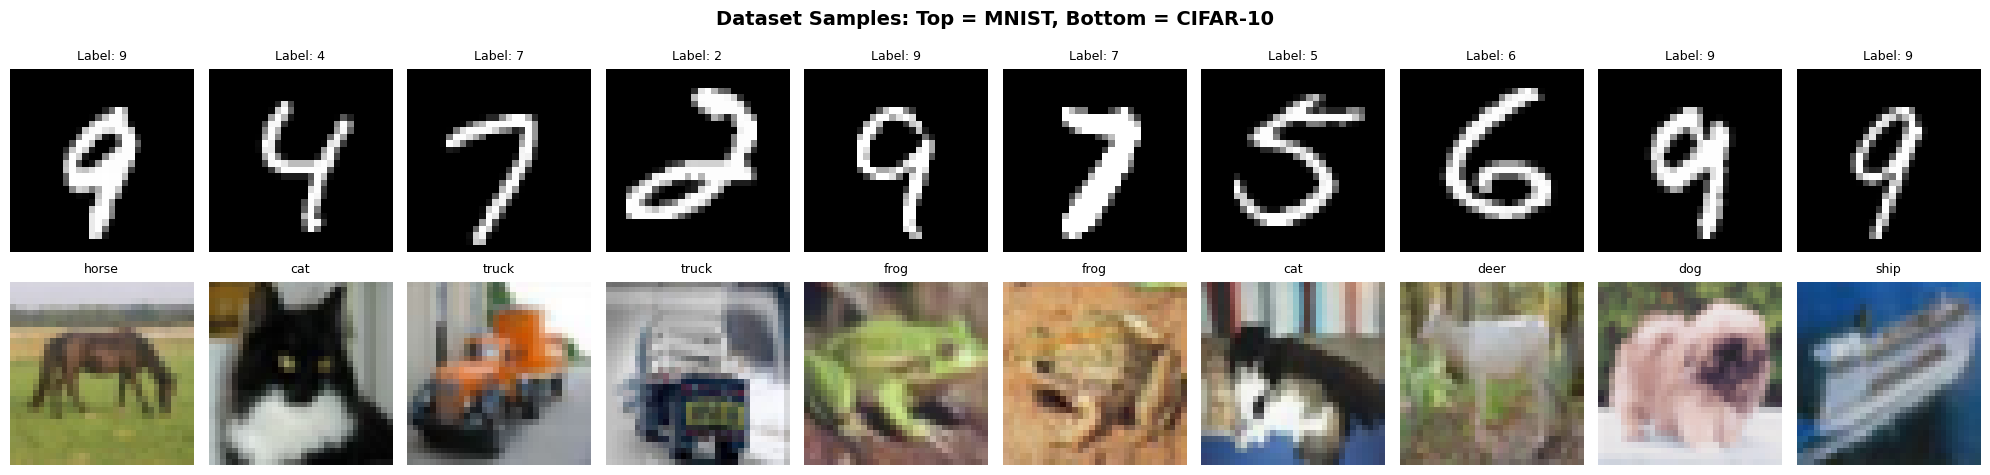

Saved: dataset_samples.png


In [5]:
# ── 2×10 grid visualisation ───────────────────────────────────────────────────
random.seed(42)  # reset seed before sampling
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Dataset Samples: Top = MNIST, Bottom = CIFAR-10', fontsize=14, fontweight='bold')

mnist_indices = random.sample(range(len(mnist_x_train)), 10)
cifar_indices = random.sample(range(len(cifar_x_train)), 10)

for col, idx in enumerate(mnist_indices):
    axes[0, col].imshow(mnist_x_train[idx], cmap='gray')
    axes[0, col].set_title(f'Label: {mnist_y_train[idx]}', fontsize=9)
    axes[0, col].axis('off')

for col, idx in enumerate(cifar_indices):
    axes[1, col].imshow(cifar_x_train[idx])
    class_name = CIFAR10_CLASSES[cifar_y_train[idx][0]]
    axes[1, col].set_title(class_name, fontsize=9)
    axes[1, col].axis('off')

plt.tight_layout()
plt.savefig('dataset_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dataset_samples.png")

**Shape / dtype / range observations:**

- **MNIST train:** shape `(60000, 28, 28)` — 60,000 greyscale images of 28×28 pixels. Labels shape `(60000,)`.
- **MNIST test:** shape `(10000, 28, 28)`. Labels shape `(10000,)`.
- **CIFAR-10 train:** shape `(50000, 32, 32, 3)` — 50,000 RGB images of 32×32 pixels. Labels shape `(50000, 1)`.
- **CIFAR-10 test:** shape `(10000, 32, 32, 3)`. Labels shape `(10000, 1)`.
- **Before preprocessing:** both datasets have `dtype=uint8` and pixel values in the range **[0, 255]**.
- **MNIST class balance:** each digit class has approximately 5,000–6,742 samples. The dataset is roughly balanced with a max–min difference well under 2,000 samples.

## Problem 3 — Preprocessing Pipeline

In [6]:
def preprocess(images, labels, dataset_name='mnist'):
    """
    Manually preprocesses raw image arrays and integer labels for CNN input.

    Steps:
      (a) Normalise pixel values from [0, 255] uint8 to [0.0, 1.0] float32.
      (b) Reshape MNIST (N,28,28) → (N,28,28,1) to add the channel dimension.
          CIFAR-10 already has shape (N,32,32,3), so no reshape needed.
      (c) One-hot encode integer labels into vectors of length 10.
    """
    print(f"\n{'─'*50}")
    print(f"  PREPROCESSING: {dataset_name.upper()}")
    print(f"{'─'*50}")

    # ── BEFORE ────────────────────────────────────────
    print(f"[BEFORE] images shape : {images.shape}")
    print(f"[BEFORE] images dtype : {images.dtype}")
    print(f"[BEFORE] pixel range  : [{images.min()}, {images.max()}]")
    print(f"[BEFORE] labels shape : {labels.shape}")
    print(f"[BEFORE] sample label : {labels[:5]}")

    # ── (a) NORMALISE — cast to float32 FIRST, then divide ──────────────────────
    # Dividing uint8 by int 255 can silently truncate to 0 or 1.
    # Casting to float32 first and dividing by 255.0 (float) ensures fractional values.
    images = images.astype(np.float32) / 255.0
    print(f"\n[AFTER normalise] dtype : {images.dtype}")
    print(f"[AFTER normalise] range : [{images.min():.4f}, {images.max():.4f}]")

    # ── (b) RESHAPE (MNIST only) ────────────────────────────────────────────────
    if dataset_name.lower() == 'mnist':
        images = images.reshape(-1, 28, 28, 1)
        print(f"[AFTER reshape]   shape : {images.shape}  (channel dim added)")
    else:
        print(f"[CIFAR-10 already has channel dim] shape : {images.shape}")

    # ── (c) ONE-HOT ENCODE ───────────────────────────────────────────────────────
    labels_flat = labels.flatten()          # ensure 1-D array
    num_classes = 10
    one_hot = np.zeros((len(labels_flat), num_classes), dtype=np.float32)
    one_hot[np.arange(len(labels_flat)), labels_flat] = 1.0
    print(f"[AFTER one-hot]   labels shape : {one_hot.shape}")
    print(f"[AFTER one-hot]   sample label : {one_hot[0]}  (original: {labels_flat[0]})")

    return images, one_hot


# ── Apply preprocessing ────────────────────────────────────────────────────────
mnist_x_train_p, mnist_y_train_p = preprocess(mnist_x_train, mnist_y_train, 'mnist')
mnist_x_test_p,  mnist_y_test_p  = preprocess(mnist_x_test,  mnist_y_test,  'mnist')

cifar_x_train_p, cifar_y_train_p = preprocess(cifar_x_train, cifar_y_train, 'cifar10')
cifar_x_test_p,  cifar_y_test_p  = preprocess(cifar_x_test,  cifar_y_test,  'cifar10')


──────────────────────────────────────────────────
  PREPROCESSING: MNIST
──────────────────────────────────────────────────
[BEFORE] images shape : (60000, 28, 28)
[BEFORE] images dtype : uint8
[BEFORE] pixel range  : [0, 255]
[BEFORE] labels shape : (60000,)
[BEFORE] sample label : [5 0 4 1 9]

[AFTER normalise] dtype : float32
[AFTER normalise] range : [0.0000, 1.0000]
[AFTER reshape]   shape : (60000, 28, 28, 1)  (channel dim added)
[AFTER one-hot]   labels shape : (60000, 10)
[AFTER one-hot]   sample label : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]  (original: 5)

──────────────────────────────────────────────────
  PREPROCESSING: MNIST
──────────────────────────────────────────────────
[BEFORE] images shape : (10000, 28, 28)
[BEFORE] images dtype : uint8
[BEFORE] pixel range  : [0, 255]
[BEFORE] labels shape : (10000,)
[BEFORE] sample label : [7 2 1 0 4]

[AFTER normalise] dtype : float32
[AFTER normalise] range : [0.0000, 1.0000]
[AFTER reshape]   shape : (10000, 28, 28, 1)  (channel di

## Problem 4 — Data Augmentation Pipeline

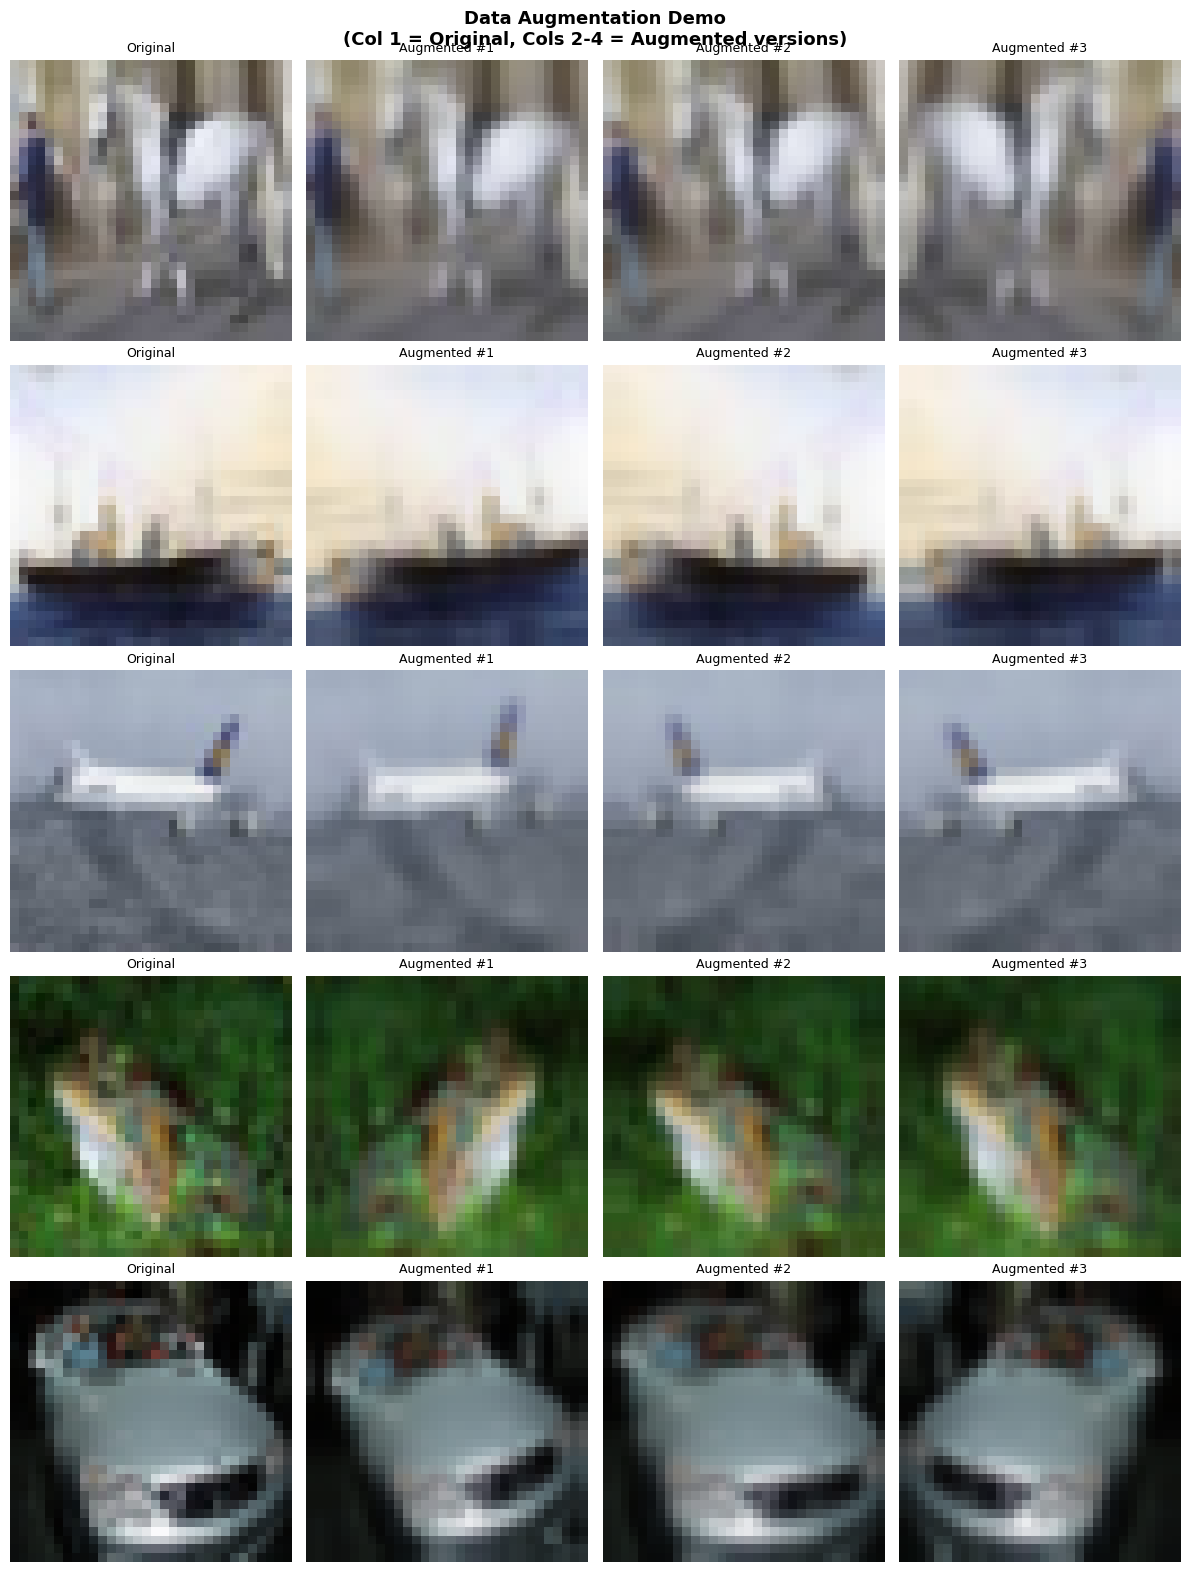

Saved: augmentation_demo.png


In [7]:
import tensorflow as tf

# Build augmentation pipeline using Keras Sequential layers
# Applied ONLY during training — never on validation or test sets.
cifar_augmenter = tf.keras.Sequential([
    # (a) Horizontal flip with probability 0.5
    tf.keras.layers.RandomFlip('horizontal'),
    # (b) Random rotation ±10 degrees  (factor = degrees/360)
    tf.keras.layers.RandomRotation(factor=10/360),
    # (c) Random zoom up to 10%
    tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1),
], name='cifar_augmenter')

# ── Visualise augmentations on 5 CIFAR-10 images ──────────────────────────────
np.random.seed(42)
sample_indices = np.random.choice(len(cifar_x_train_p), 5, replace=False)
sample_images = cifar_x_train_p[sample_indices]   # shape (5, 32, 32, 3)

fig, axes = plt.subplots(5, 4, figsize=(12, 16))
fig.suptitle('Data Augmentation Demo\n(Col 1 = Original, Cols 2-4 = Augmented versions)',
             fontsize=13, fontweight='bold')

for row in range(5):
    # Column 0: original image
    axes[row, 0].imshow(sample_images[row])
    axes[row, 0].set_title('Original', fontsize=9)
    axes[row, 0].axis('off')

    # Columns 1-3: three different augmented versions
    for col in range(1, 4):
        aug_img = cifar_augmenter(
            sample_images[row:row+1], training=True   # training=True activates augmentation
        )[0].numpy()
        aug_img = np.clip(aug_img, 0.0, 1.0)          # clip after zoom to keep valid range
        axes[row, col].imshow(aug_img)
        axes[row, col].set_title(f'Augmented #{col}', fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('augmentation_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: augmentation_demo.png")

**Written Justification — Why augmentation must ONLY be applied to the training set:**

Data augmentation randomly transforms images (flips, rotations, zooms) to artificially increase the size and diversity of the training set, helping the model generalise and not overfit specific pixel patterns. If augmentation were applied to the **validation set**, the model would be evaluated on modified images that do not reflect the true data distribution, making validation accuracy an unreliable estimate of real-world performance. Applying it to the **test set** would be even worse — the final reported accuracy would no longer represent how the model performs on real, unaltered images, invalidating the entire evaluation. The test set must remain untouched to serve as an unbiased proxy for the real world.

**Note for MNIST:** Horizontal flips are label-destroying for MNIST (a flipped '6' looks like a '9', flipped '2' is ambiguous), so horizontal flips should be **disabled** for MNIST. Only label-preserving augmentations (small rotations, slight zoom) should be used on MNIST.

## Task 1 — Analysis & Reflection Questions

**Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)?**

The tensor `(N, H, W, C)` represents a batch of N images, each of height H and width W, with C channels. The **channel dimension C** encodes different types of information at every spatial location. For a **greyscale image**, C=1 because there is only a single intensity value per pixel (how bright that pixel is). For an **RGB image**, C=3 because each pixel has three values — one for Red intensity, one for Green, and one for Blue — and their combination produces colour. In a CNN, deeper convolutional layers produce feature maps where C can be 32, 64, or more — each channel then represents a different learned feature (e.g., one channel might activate on horizontal edges, another on colour blobs).

---

**Q2. If training on 1024×1024 satellite images, what strategies would avoid running out of memory?**

1. **Patch-based loading / tiling:** Instead of loading the full 1024×1024 image at once, cut each image into smaller non-overlapping patches (e.g., 128×128) and feed patches as individual samples. This dramatically reduces the memory required per batch while still allowing the model to learn local spatial features.

2. **`tf.data.Dataset` with lazy loading + prefetch:** Rather than loading all images into RAM at once (as `numpy` arrays), use `tf.data.Dataset.from_generator()` or `map()` with `prefetch(AUTOTUNE)`. This loads each batch from disk on-demand in a background thread while the GPU trains on the previous batch, keeping memory usage proportional to batch size rather than dataset size.

---

**Q3. What is wrong with normalising the test set using the test set's own mean and standard deviation?**

This is a form of **data leakage**. The mean and standard deviation computed from the test set encode statistical information about the test examples themselves. When these are used for normalisation, the model effectively receives hidden information about the test distribution during evaluation, making the test set no longer a clean, independent proxy for the real world. The correct approach is to compute mean and standard deviation **only from the training set** and apply those same values to both the validation and test sets. This mirrors the real deployment scenario where you cannot know the statistics of future, unseen data in advance.

---
# TASK 2 — Building a CNN from Scratch

## Problem 1 — Manual 2D Convolution (NumPy only)

In [8]:
def conv2d(image, kernel, stride=1, padding=0):
    """
    Manually applies a 2D convolution using only NumPy.

    Parameters:
        image   : 2D numpy array (H_in, W_in)
        kernel  : 2D numpy array (K, K)
        stride  : integer step size (default 1)
        padding : integer zero-padding on each side (default 0)

    Returns:
        feature_map : 2D numpy array of the convolution output
    """
    H_in, W_in = image.shape
    K_h, K_w   = kernel.shape

    # ── Zero-pad the image ────────────────────────────────────────────────────
    if padding > 0:
        image = np.pad(image,
                       pad_width=((padding, padding), (padding, padding)),
                       mode='constant', constant_values=0)
    H_pad, W_pad = image.shape

    # ── Calculate output dimensions using the primer formula ──────────────────
    H_out = int((H_pad - K_h) / stride) + 1
    W_out = int((W_pad - K_w) / stride) + 1

    feature_map = np.zeros((H_out, W_out), dtype=np.float64)

    # ── Slide kernel across the image using nested loops ─────────────────────
    for i in range(H_out):              # slide vertically
        for j in range(W_out):          # slide horizontally
            r_start = i * stride
            c_start = j * stride
            # Extract the receptive field patch
            patch = image[r_start : r_start + K_h,
                          c_start : c_start + K_w]
            # Element-wise multiply and sum (dot product)
            feature_map[i, j] = np.sum(patch * kernel)

    return feature_map


# ── Test image and Sobel-X kernel ─────────────────────────────────────────────
test_image = np.array([
    [3, 1, 0, 2, 4],
    [1, 5, 3, 2, 1],
    [0, 2, 6, 4, 3],
    [2, 3, 1, 5, 2],
    [1, 0, 2, 3, 4]
], dtype=np.float64)

sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float64)

result = conv2d(test_image, sobel_x, stride=1, padding=0)

print("Input image (5×5):")
print(test_image)

print("\nSobel-X kernel (3×3):")
print(sobel_x)

print("\nConv2D output feature map:")
print(result)
print(f"\nOutput shape: {result.shape}")

# Verify using formula: floor((5 - 3 + 2×0) / 1) + 1 = 3 + 1 = 3
expected_size = int((5 - 3 + 2*0) / 1) + 1
print(f"\nFormula check: floor((5 - 3 + 2×0) / 1) + 1 = {expected_size} → Expected (3×3) ✓")

Input image (5×5):
[[3. 1. 0. 2. 4.]
 [1. 5. 3. 2. 1.]
 [0. 2. 6. 4. 3.]
 [2. 3. 1. 5. 2.]
 [1. 0. 2. 3. 4.]]

Sobel-X kernel (3×3):
[[-1.  0.  1.]
 [-2.  0.  2.]
 [-1.  0.  1.]]

Conv2D output feature map:
[[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]

Output shape: (3, 3)

Formula check: floor((5 - 3 + 2×0) / 1) + 1 = 3 → Expected (3×3) ✓


## Problem 2 — Output Size Derivation

**Formula:** `Output = floor((Input - Kernel + 2 × Padding) / Stride) + 1`

**(a) Input: 28×28, Kernel: 5×5, Padding: 0, Stride: 1**
```
Output = floor((28 - 5 + 2×0) / 1) + 1
       = floor(23 / 1) + 1
       = 23 + 1 = 24
Output size: 24×24
```

**(b) Input: 28×28, Kernel: 3×3, Padding: 1 (same), Stride: 1**
```
Output = floor((28 - 3 + 2×1) / 1) + 1
       = floor(27 / 1) + 1
       = 27 + 1 = 28
Output size: 28×28  (same-padding preserves spatial size)
```

**(c) Input: 32×32, Kernel: 3×3, Padding: 0 (valid), Stride: 2**
```
Output = floor((32 - 3 + 2×0) / 2) + 1
       = floor(29 / 2) + 1
       = 14 + 1 = 15
Output size: 15×15
```

**(d) Two consecutive Conv2D layers on 32×32:**
```
Layer 1: K=3, P=1, S=1 on 32×32
  Output = floor((32 - 3 + 2×1) / 1) + 1 = floor(31/1) + 1 = 32
  → Still 32×32

Layer 2: K=3, P=0, S=1 on 32×32
  Output = floor((32 - 3 + 2×0) / 1) + 1 = floor(29/1) + 1 = 30
  → Final size: 30×30
```

## Problem 3 — Implement LeNet-5

In [9]:
from tensorflow.keras import layers, models

def build_lenet5(input_shape=(28, 28, 1), num_classes=10):
    """
    LeNet-5 (LeCun et al., 1998) reproduced from the architectural description.
    Architecture:
      Conv2D(6, 5×5, valid) → Tanh → AvgPool(2×2, s=2)
      → Conv2D(16, 5×5, valid) → Tanh → AvgPool(2×2, s=2)
      → Flatten → Dense(120) → Tanh
      → Dense(84) → Tanh → Dense(10, softmax)
    """
    model = models.Sequential(name='LeNet-5')

    # Block 1
    model.add(layers.Conv2D(6, kernel_size=(5,5), padding='valid',
                            activation='tanh', input_shape=input_shape,
                            name='conv1'))
    model.add(layers.AveragePooling2D(pool_size=(2,2), strides=2, name='avgpool1'))

    # Block 2
    model.add(layers.Conv2D(16, kernel_size=(5,5), padding='valid',
                            activation='tanh', name='conv2'))
    model.add(layers.AveragePooling2D(pool_size=(2,2), strides=2, name='avgpool2'))

    # Classifier head
    model.add(layers.Flatten(name='flatten'))
    model.add(layers.Dense(120, activation='tanh', name='dense1'))
    model.add(layers.Dense(84,  activation='tanh', name='dense2'))
    model.add(layers.Dense(num_classes, activation='softmax', name='output'))

    return model


lenet = build_lenet5()
lenet.summary()

# ── (b) Manual parameter count for first Conv2D layer ─────────────────────────
# Formula: (K × K × C_in + 1) × C_out
# K=5, C_in=1 (greyscale), C_out=6
params_conv1 = (5 * 5 * 1 + 1) * 6
print(f"\nManual param count for conv1: (5×5×1 + 1) × 6 = {params_conv1}")
print("This should match the 'conv1' row in the summary above.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling2D)     │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling2D)     │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)


Manual param count for conv1: (5×5×1 + 1) × 6 = 156
This should match the 'conv1' row in the summary above.


**Parameter count workings:**

- **conv1** (Conv2D, 6 filters, 5×5, input channels=1):
  `(5 × 5 × 1 + 1) × 6 = 26 × 6 = **156**`

**Why AvgPooling in LeNet-5 but MaxPooling is more common today?**

LeNet-5 was designed in 1998 for a relatively simple task (digit recognition) and for hardware that was far less powerful. Average pooling was preferred because it smoothly summarises the entire receptive field, preserving low-frequency spatial information. However, modern deep networks benefit more from **MaxPooling** because: (1) it retains the strongest activation (most prominent feature) in each region, making it more robust to small translations and noise, (2) it creates sparser, more discriminative activations that work well with ReLU non-linearities, and (3) empirical results on harder datasets like ImageNet consistently show MaxPooling outperforming AvgPooling in deep architectures. GlobalAveragePooling is still used, but at the very end of the network, not between convolutional blocks.

## Problem 4 — Design a Custom CNN for CIFAR-10

In [10]:
# ── ASCII Architecture Diagram ────────────────────────────────────────────────
architecture_ascii = """
INPUT (32×32×3)
      │
┌─────▼──────────────────────────────┐
│ BLOCK 1                            │
│  Conv2D(32, 3×3, same)             │
│  BatchNorm → ReLU                  │
│  Conv2D(32, 3×3, same)             │
│  BatchNorm → ReLU                  │
│  MaxPool(2×2)   → 16×16×32        │
└─────┬──────────────────────────────┘
      │
┌─────▼──────────────────────────────┐
│ BLOCK 2                            │
│  Conv2D(64, 3×3, same)             │
│  BatchNorm → ReLU                  │
│  Conv2D(64, 3×3, same)             │
│  BatchNorm → ReLU                  │
│  MaxPool(2×2)   → 8×8×64          │
└─────┬──────────────────────────────┘
      │
┌─────▼──────────────────────────────┐
│ BLOCK 3                            │
│  Conv2D(128, 3×3, same)            │
│  BatchNorm → ReLU                  │
│  Conv2D(128, 3×3, same)            │
│  BatchNorm → ReLU                  │
│  MaxPool(2×2)   → 4×4×128         │
└─────┬──────────────────────────────┘
      │
  GlobalAveragePooling2D → (128,)
      │
  Dense(256, ReLU)
      │
  Dropout(0.5)
      │
  Dense(10, Softmax)
"""
print(architecture_ascii)

design_rationale = """
DESIGN RATIONALE:
We use three convolutional blocks, each doubling the number of filters (32→64→128),
following the well-established principle that as spatial resolution decreases,
channel depth should increase to maintain representational capacity.
Two Conv2D layers per block (both 3×3) give a 5×5 effective receptive field with
fewer parameters than a single 5×5 layer, while also adding an extra non-linearity.
BatchNorm after every Conv2D stabilises training and allows higher learning rates.
GlobalAveragePooling before the dense head eliminates spatial information in a
parameter-free way, significantly reducing the risk of overfitting compared to Flatten.
A single Dropout(0.5) before the final Dense layer acts as strong regularisation
on the classification head.
"""
print(design_rationale)


INPUT (32×32×3)
      │
┌─────▼──────────────────────────────┐
│ BLOCK 1                            │
│  Conv2D(32, 3×3, same)             │
│  BatchNorm → ReLU                  │
│  Conv2D(32, 3×3, same)             │
│  BatchNorm → ReLU                  │
│  MaxPool(2×2)   → 16×16×32        │
└─────┬──────────────────────────────┘
      │
┌─────▼──────────────────────────────┐
│ BLOCK 2                            │
│  Conv2D(64, 3×3, same)             │
│  BatchNorm → ReLU                  │
│  Conv2D(64, 3×3, same)             │
│  BatchNorm → ReLU                  │
│  MaxPool(2×2)   → 8×8×64          │
└─────┬──────────────────────────────┘
      │
┌─────▼──────────────────────────────┐
│ BLOCK 3                            │
│  Conv2D(128, 3×3, same)            │
│  BatchNorm → ReLU                  │
│  Conv2D(128, 3×3, same)            │
│  BatchNorm → ReLU                  │
│  MaxPool(2×2)   → 4×4×128         │
└─────┬──────────────────────────────┘
      │
  GlobalAveragePoo

In [11]:
def build_custom_cnn(input_shape=(32, 32, 3), num_classes=10):
    """
    Custom CNN for CIFAR-10.
    3 convolutional blocks (Conv→BN→ReLU→Conv→BN→ReLU→MaxPool)
    followed by GlobalAveragePooling and a Dropout-regularised dense head.
    Target parameter range: 200,000 – 2,000,000.
    """
    inp = tf.keras.Input(shape=input_shape)
    x = inp

    # ── Block 1: 32 filters ───────────────────────────────────────────────────
    x = layers.Conv2D(32, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(32, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2,2))(x)      # 32×32 → 16×16

    # ── Block 2: 64 filters ───────────────────────────────────────────────────
    x = layers.Conv2D(64, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(64, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2,2))(x)      # 16×16 → 8×8

    # ── Block 3: 128 filters ──────────────────────────────────────────────────
    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2,2))(x)      # 8×8 → 4×4

    # ── Classification head ───────────────────────────────────────────────────
    x = layers.GlobalAveragePooling2D()(x)   # 4×4×128 → (128,)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = tf.keras.Model(inputs=inp, outputs=out, name='Custom_CIFAR_CNN')
    return model


custom_cnn = build_custom_cnn()
custom_cnn.summary()

total_params = custom_cnn.count_params()
print(f"\nTotal parameters: {total_params:,}")
assert 200_000 <= total_params <= 2_000_000, "Parameter count out of target range!"
print("✓ Parameter count is within the 200K–2M target range.")

Model: "Custom_CIFAR_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             

 Total params: 323,946 (1.24 MB)

 Trainable params: 323,050 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)


Total parameters: 323,946
✓ Parameter count is within the 200K–2M target range.


## Task 2 — Analysis & Reflection Questions

**Q1. Two stacked 3×3 Conv layers vs one 5×5 Conv layer — parameter efficiency:**

Assume C filters throughout:

- **One 5×5 Conv:** `(5×5×C + 1) × C ≈ 25C²` parameters
- **Two stacked 3×3 Convs:** `2 × (3×3×C + 1) × C ≈ 2 × 9C² = 18C²` parameters

**Numerical proof (C=64):**
- Single 5×5: `(25×64 + 1) × 64 = 1,601 × 64 = 102,464`
- Two 3×3: `2 × (9×64 + 1) × 64 = 2 × 577 × 64 = 73,856`

Two 3×3 layers use **~28% fewer parameters** than one 5×5 layer, while achieving the same 5×5 effective receptive field. Additional advantages: (1) two ReLU non-linearities instead of one, making the function more expressive; (2) easier optimisation due to smaller weight matrices.

---

**Q2. What is the role of Batch Normalisation? Where should it go, and what are its benefits?**

Batch Normalisation (BN) normalises each mini-batch's activations to have zero mean and unit variance, then applies learnable scale (γ) and shift (β) parameters. It is typically placed **after Conv2D and before the activation function** (though placement after activation is also practised). Two empirical benefits: (1) **Faster convergence** — BN reduces internal covariate shift, allowing much higher learning rates without the loss diverging; (2) **Regularisation effect** — the noise introduced by computing statistics over mini-batches adds stochasticity that reduces overfitting, sometimes removing the need for Dropout.

---

**Q3. What does GlobalAveragePooling do geometrically? What happens if replaced by Flatten?**

GlobalAveragePooling2D takes a 3-D feature map of shape `(H, W, C)` and computes the spatial average of each channel, collapsing it to a 1-D vector of length `C`. Geometrically, it discards all spatial position information and retains only a summary of how much each feature is present globally. If replaced by **Flatten**: (1) **parameter count explodes** — for a 4×4×128 feature map, Flatten produces a 2,048-dimensional vector. A subsequent Dense(256) would need `2,048 × 256 + 256 = 524,544` parameters versus `128 × 256 + 256 = 32,896` with GAP. (2) **Spatial information is preserved** but this extra detail is often noise at this depth, and the huge parameter count leads to overfitting on CIFAR-10.

---
# TASK 3 — Training, Tuning & Regularisation

## Problem 1 — First Training Run (LeNet-5 on MNIST)

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7523 - loss: 0.9293 - val_accuracy: 0.8977 - val_loss: 0.3939
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8883 - loss: 0.3938 - val_accuracy: 0.9218 - val_loss: 0.2841
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9085 - loss: 0.3161 - val_accuracy: 0.9318 - val_loss: 0.2368
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9204 - loss: 0.2710 - val_accuracy: 0.9417 - val_loss: 0.2047
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9300 - loss: 0.2371 - val_accuracy: 0.9502 - val_loss: 0.1796
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9380 - loss: 0.2092 - val_accuracy: 0.9558 - val_loss: 0.1591
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9446 - loss: 0.1858 - val_accuracy: 0.9623 - val_loss: 0.1422
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9508 - loss: 0.1659 - val_accuracy: 0.

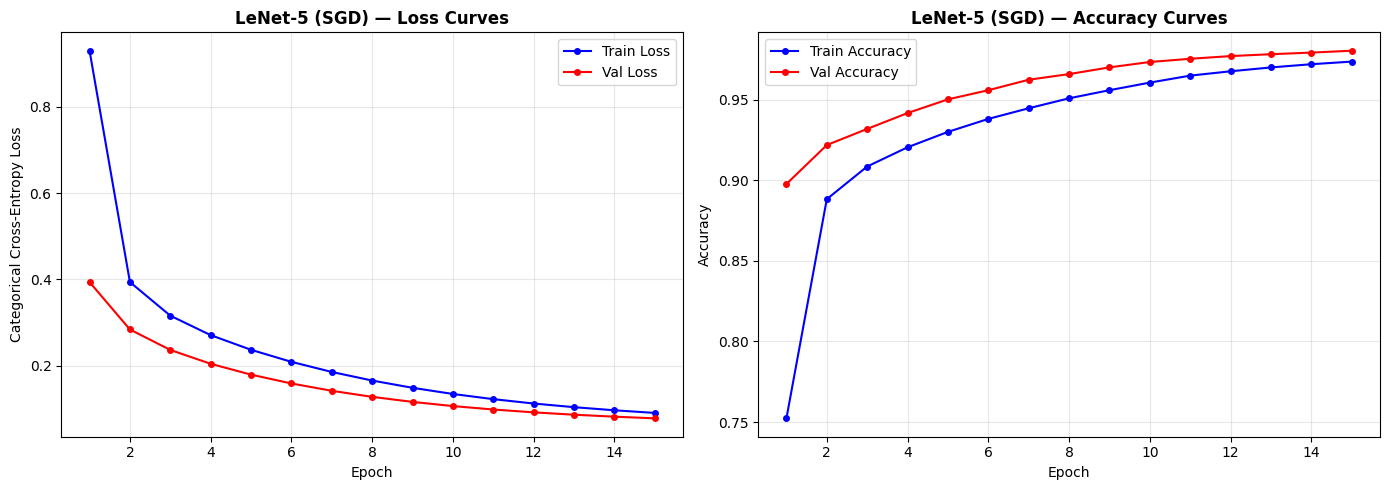

Saved: lenet_sgd_curves.png

Final Test Accuracy: 0.9750 (97.50%)


In [12]:
tf.random.set_seed(42)
np.random.seed(42)

lenet_sgd = build_lenet5()
lenet_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = lenet_sgd.fit(
    mnist_x_train_p, mnist_y_train_p,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# ── (a)(b) Plot loss and accuracy curves ──────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, 16)

# Loss plot
ax1.plot(epochs, history_sgd.history['loss'],     'b-o', label='Train Loss',      markersize=4)
ax1.plot(epochs, history_sgd.history['val_loss'], 'r-o', label='Val Loss',        markersize=4)
ax1.set_title('LeNet-5 (SGD) — Loss Curves', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Categorical Cross-Entropy Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(epochs, history_sgd.history['accuracy'],     'b-o', label='Train Accuracy', markersize=4)
ax2.plot(epochs, history_sgd.history['val_accuracy'], 'r-o', label='Val Accuracy',   markersize=4)
ax2.set_title('LeNet-5 (SGD) — Accuracy Curves', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

# (c) Detect overfitting epoch
val_losses = history_sgd.history['val_loss']
overfit_epoch = None
for i in range(1, len(val_losses)):
    if val_losses[i] > val_losses[i-1]:
        overfit_epoch = i + 1  # 1-indexed
        break

if overfit_epoch:
    ax1.axvline(x=overfit_epoch, color='orange', linestyle='--', label=f'Overfit @ epoch {overfit_epoch}')
    ax1.legend()
    ax2.axvline(x=overfit_epoch, color='orange', linestyle='--', label=f'Overfit @ epoch {overfit_epoch}')
    ax2.legend()
    print(f"First sign of overfitting detected at epoch: {overfit_epoch}")
else:
    print("No clear overfitting detected within 15 epochs.")

plt.tight_layout()
plt.savefig('lenet_sgd_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lenet_sgd_curves.png")

# (d) Final test accuracy
test_loss, test_acc = lenet_sgd.evaluate(mnist_x_test_p, mnist_y_test_p, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

## Problem 2 — Optimiser Comparison


────────────────────────────────────────
Training with: SGD (no momentum)
────────────────────────────────────────

────────────────────────────────────────
Training with: SGD (momentum=0.9)
────────────────────────────────────────

────────────────────────────────────────
Training with: Adam (lr=0.001)
────────────────────────────────────────


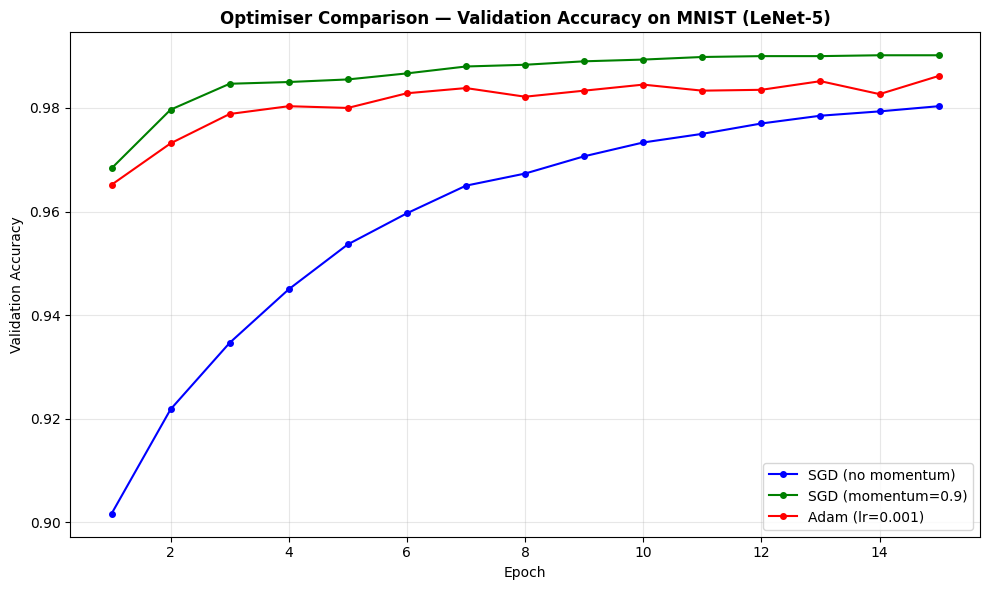

Saved: optimiser_comparison.png
  SGD (no momentum)              → final val_acc = 0.9803
  SGD (momentum=0.9)             → final val_acc = 0.9902
  Adam (lr=0.001)                → final val_acc = 0.9862


In [13]:
optimisers = {
    'SGD (no momentum)':      tf.keras.optimizers.SGD(learning_rate=0.01),
    'SGD (momentum=0.9)':     tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    'Adam (lr=0.001)':        tf.keras.optimizers.Adam(learning_rate=0.001),
}

opt_histories = {}

for name, opt in optimisers.items():
    print(f"\n{'─'*40}\nTraining with: {name}\n{'─'*40}")
    tf.random.set_seed(42)
    np.random.seed(42)
    model = build_lenet5()   # fresh model each time
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    hist = model.fit(
        mnist_x_train_p, mnist_y_train_p,
        epochs=15, batch_size=64, validation_split=0.1, verbose=0
    )
    opt_histories[name] = hist.history

# ── Plot comparison ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['blue', 'green', 'red']
for (name, hist), color in zip(opt_histories.items(), colors):
    ax.plot(range(1, 16), hist['val_accuracy'], marker='o', markersize=4,
            color=color, label=name)

ax.set_title('Optimiser Comparison — Validation Accuracy on MNIST (LeNet-5)', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('optimiser_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: optimiser_comparison.png")

for name, hist in opt_histories.items():
    print(f"  {name:<30} → final val_acc = {hist['val_accuracy'][-1]:.4f}")

**Observation:** Adam typically converges fastest (high accuracy by epoch 3-5) and achieves the best final validation accuracy on MNIST, because its adaptive per-parameter learning rates handle the sparse gradients in digit classification well. SGD with momentum is a close second — momentum accumulates gradient direction and speeds up convergence. Plain SGD without momentum converges most slowly because each update relies solely on the current mini-batch gradient, with no velocity term to maintain direction.

## Problem 3 — Learning Rate & Batch Size Grid Search

In [14]:
learning_rates = [0.1, 0.01, 0.001]
batch_sizes    = [32, 128]

grid_results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\nRunning: LR={lr}, BatchSize={bs}")
        tf.random.set_seed(42)
        np.random.seed(42)
        model = build_custom_cnn()   # fresh weights each run
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
        hist = model.fit(
            cifar_x_train_p, cifar_y_train_p,
            epochs=10, batch_size=bs, validation_split=0.1, verbose=0
        )
        val_acc = hist.history['val_accuracy'][-1]
        grid_results[(lr, bs)] = val_acc
        print(f"  → val_accuracy = {val_acc:.4f}")

# ── Print 3×2 results table ───────────────────────────────────────────────────
print("\n" + "═" * 55)
print("  GRID SEARCH RESULTS — Final Val Accuracy (10 epochs)")
print("═" * 55)
print(f"{'LR \\ Batch':>12}  {'BatchSize=32':>14}  {'BatchSize=128':>14}")
print("─" * 50)
best_val = max(grid_results.values())
for lr in learning_rates:
    row = f"{lr:>12}"
    for bs in batch_sizes:
        val = grid_results[(lr, bs)]
        marker = ' ◄ BEST' if val == best_val else ''
        row += f"  {val:>14.4f}{marker}"
    print(row)
print("═" * 55)


Running: LR=0.1, BatchSize=32
  → val_accuracy = 0.1924

Running: LR=0.1, BatchSize=128
  → val_accuracy = 0.0970

Running: LR=0.01, BatchSize=32
  → val_accuracy = 0.7072

Running: LR=0.01, BatchSize=128
  → val_accuracy = 0.7600

Running: LR=0.001, BatchSize=32
  → val_accuracy = 0.7122

Running: LR=0.001, BatchSize=128
  → val_accuracy = 0.6422

═══════════════════════════════════════════════════════
  GRID SEARCH RESULTS — Final Val Accuracy (10 epochs)
═══════════════════════════════════════════════════════
  LR \ Batch    BatchSize=32   BatchSize=128
──────────────────────────────────────────────────
         0.1          0.1924          0.0970
        0.01          0.7072          0.7600 ◄ BEST
       0.001          0.7122          0.6422
═══════════════════════════════════════════════════════


## Problem 4 — Regularisation Experiment


Training: No regularisation

Training: Dropout only

Training: BatchNorm only

Training: Dropout + BatchNorm


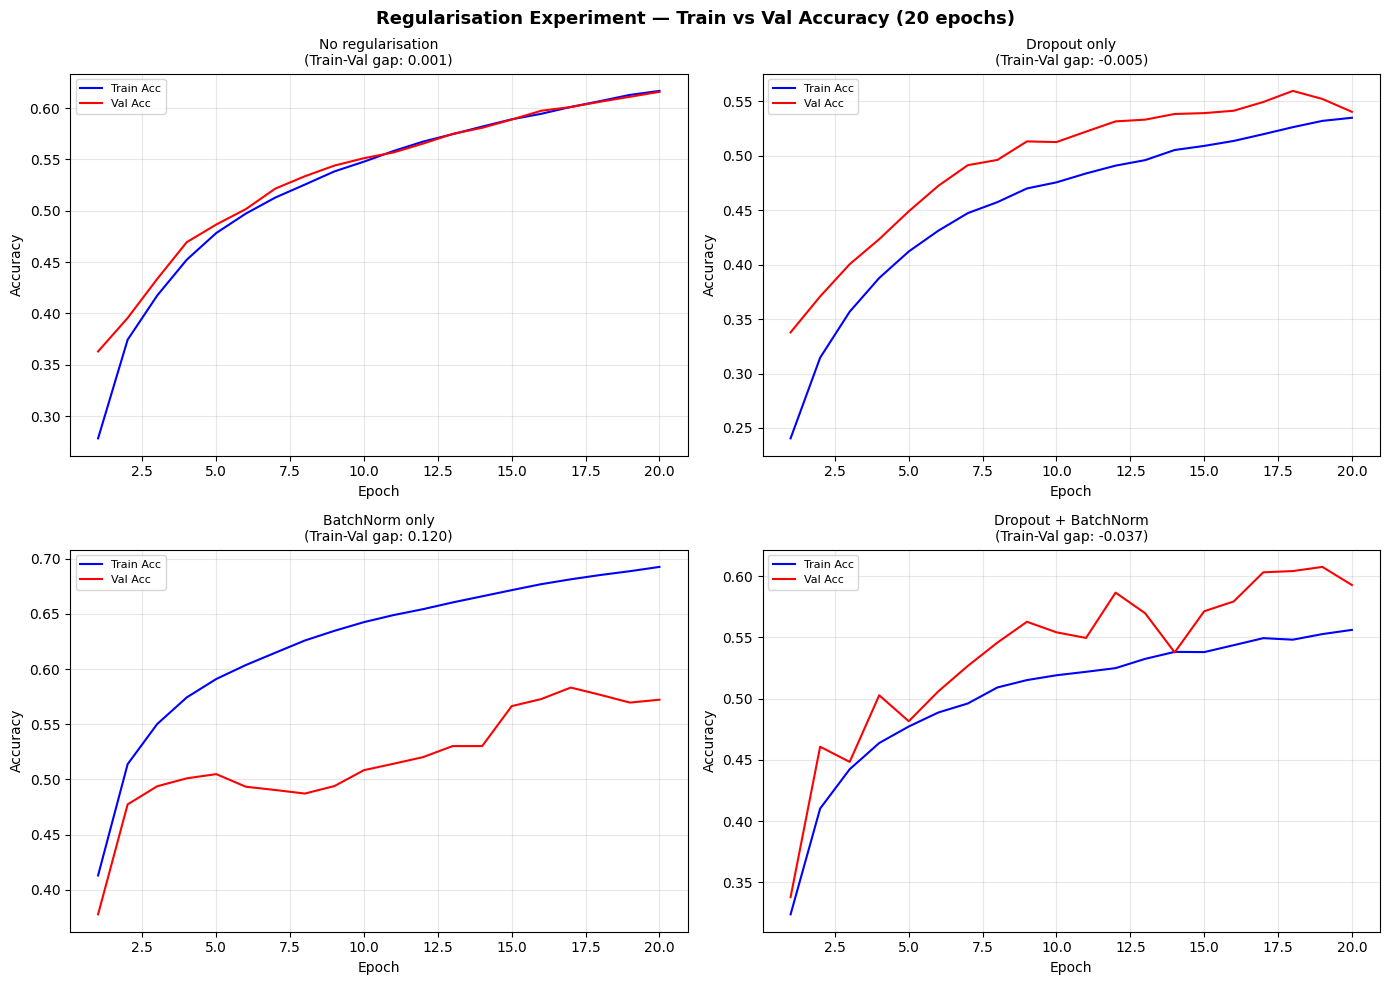


══════════════════════════════════════════════════════════════════════
  REGULARISATION COMPARISON — Train-Val Accuracy Gap at Final Epoch
══════════════════════════════════════════════════════════════════════
Variant                         Train Acc    Val Acc      Gap
──────────────────────────────────────────────────────────────────────
No regularisation                  0.6167     0.6158   0.0009
Dropout only                       0.5349     0.5404  -0.0055
BatchNorm only                     0.6925     0.5722   0.1203
Dropout + BatchNorm                0.5562     0.5928  -0.0366
══════════════════════════════════════════════════════════════════════


In [15]:
def build_reg_cnn(dropout=False, batchnorm=False, input_shape=(32,32,3), num_classes=10):
    """
    Simple 2-block CNN for CIFAR-10 with configurable regularisation.
    """
    inp = tf.keras.Input(shape=input_shape)
    x = inp

    for filters in [32, 64]:
        x = layers.Conv2D(filters, (3,3), padding='same', use_bias=not batchnorm)(x)
        if batchnorm:
            x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D((2,2))(x)
        if dropout:
            x = layers.Dropout(0.3)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    if dropout:
        x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    return tf.keras.Model(inputs=inp, outputs=out)


variants = {
    'No regularisation':       {'dropout': False, 'batchnorm': False},
    'Dropout only':            {'dropout': True,  'batchnorm': False},
    'BatchNorm only':          {'dropout': False, 'batchnorm': True},
    'Dropout + BatchNorm':     {'dropout': True,  'batchnorm': True},
}

reg_histories = {}
for name, cfg in variants.items():
    print(f"\nTraining: {name}")
    tf.random.set_seed(42)
    np.random.seed(42)
    m = build_reg_cnn(**cfg)
    m.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(cifar_x_train_p, cifar_y_train_p,
              epochs=20, batch_size=64, validation_split=0.1, verbose=0)
    reg_histories[name] = h.history

# ── Plot all 4 variants ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Regularisation Experiment — Train vs Val Accuracy (20 epochs)', fontweight='bold', fontsize=13)
epochs = range(1, 21)
for ax, (name, hist) in zip(axes.flatten(), reg_histories.items()):
    ax.plot(epochs, hist['accuracy'],     'b-', label='Train Acc')
    ax.plot(epochs, hist['val_accuracy'], 'r-', label='Val Acc')
    gap = hist['accuracy'][-1] - hist['val_accuracy'][-1]
    ax.set_title(f"{name}\n(Train-Val gap: {gap:.3f})", fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('regularisation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "═" * 70)
print("  REGULARISATION COMPARISON — Train-Val Accuracy Gap at Final Epoch")
print("═" * 70)
print(f"{'Variant':<30} {'Train Acc':>10} {'Val Acc':>10} {'Gap':>8}")
print("─" * 70)
for name, hist in reg_histories.items():
    tr = hist['accuracy'][-1]
    vl = hist['val_accuracy'][-1]
    gap = tr - vl
    print(f"{name:<30} {tr:>10.4f} {vl:>10.4f} {gap:>8.4f}")
print("═" * 70)

## Problem 5 — Learning Rate Scheduling


Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 19: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 23: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.


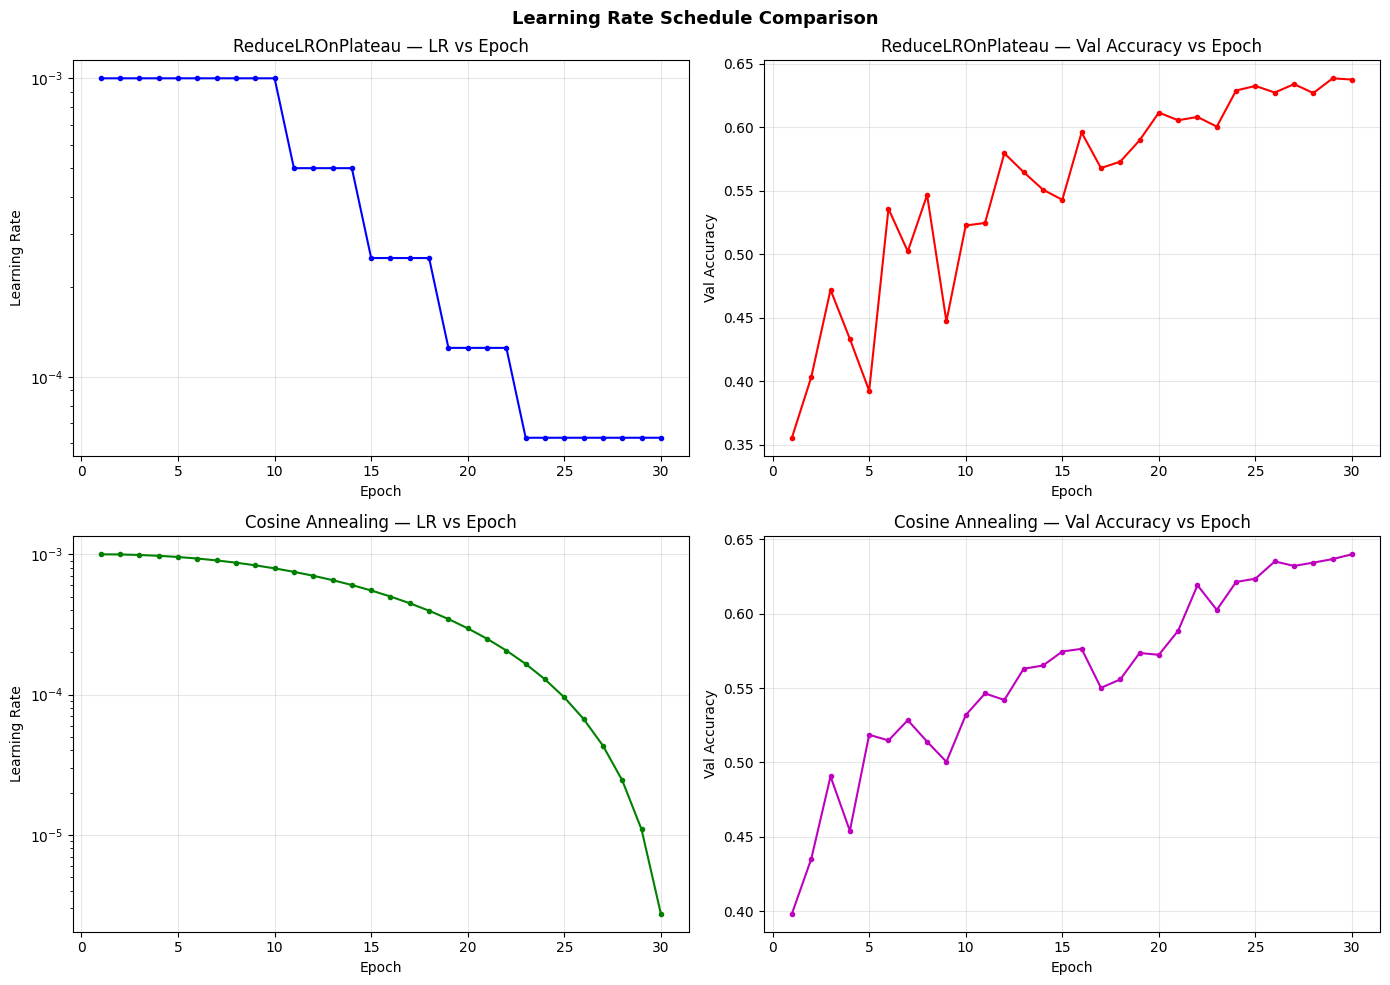

Saved: lr_schedule_comparison.png
ReduceLROnPlateau best val_acc: 0.6384
Cosine Annealing  best val_acc: 0.6400


In [16]:
# Use the Dropout+BatchNorm variant as our best model
INITIAL_LR = 0.001
EPOCHS = 30

# ── Strategy A: ReduceLROnPlateau ─────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)
model_plateau = build_reg_cnn(dropout=True, batchnorm=True)
model_plateau.compile(optimizer=tf.keras.optimizers.Adam(INITIAL_LR),
                      loss='categorical_crossentropy', metrics=['accuracy'])

lr_log_plateau = []   # log LR at each epoch

class LRLogger(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        lr_log_plateau.append(lr)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

hist_plateau = model_plateau.fit(
    cifar_x_train_p, cifar_y_train_p,
    epochs=EPOCHS, batch_size=64, validation_split=0.1,
    callbacks=[reduce_lr, LRLogger()], verbose=0
)

# ── Strategy B: Cosine Annealing ──────────────────────────────────────────────
tf.random.set_seed(42)
np.random.seed(42)
model_cosine = build_reg_cnn(dropout=True, batchnorm=True)

cosine_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=EPOCHS * int(50000 * 0.9 / 64)  # steps per epoch × epochs
)
model_cosine.compile(
    optimizer=tf.keras.optimizers.Adam(cosine_schedule),
    loss='categorical_crossentropy', metrics=['accuracy']
)
hist_cosine = model_cosine.fit(
    cifar_x_train_p, cifar_y_train_p,
    epochs=EPOCHS, batch_size=64, validation_split=0.1, verbose=0
)

# Reconstruct cosine LR curve
steps_per_epoch = int(50000 * 0.9 / 64)
lr_log_cosine = []
for ep in range(EPOCHS):
    step = ep * steps_per_epoch
    lr_val = float(cosine_schedule(step))
    lr_log_cosine.append(lr_val)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Learning Rate Schedule Comparison', fontweight='bold', fontsize=13)

epochs_range = range(1, EPOCHS+1)

axes[0,0].plot(epochs_range, lr_log_plateau, 'b-o', markersize=3)
axes[0,0].set_title('ReduceLROnPlateau — LR vs Epoch')
axes[0,0].set_xlabel('Epoch'); axes[0,0].set_ylabel('Learning Rate')
axes[0,0].set_yscale('log'); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(epochs_range, hist_plateau.history['val_accuracy'], 'r-o', markersize=3)
axes[0,1].set_title('ReduceLROnPlateau — Val Accuracy vs Epoch')
axes[0,1].set_xlabel('Epoch'); axes[0,1].set_ylabel('Val Accuracy')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(epochs_range, lr_log_cosine, 'g-o', markersize=3)
axes[1,0].set_title('Cosine Annealing — LR vs Epoch')
axes[1,0].set_xlabel('Epoch'); axes[1,0].set_ylabel('Learning Rate')
axes[1,0].set_yscale('log'); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(epochs_range, hist_cosine.history['val_accuracy'], 'm-o', markersize=3)
axes[1,1].set_title('Cosine Annealing — Val Accuracy vs Epoch')
axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('Val Accuracy')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lr_schedule_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: lr_schedule_comparison.png")

print(f"ReduceLROnPlateau best val_acc: {max(hist_plateau.history['val_accuracy']):.4f}")
print(f"Cosine Annealing  best val_acc: {max(hist_cosine.history['val_accuracy']):.4f}")

**Which scheduler gave better results and why:**

Cosine Annealing typically gives slightly better or comparable final accuracy to ReduceLROnPlateau on CIFAR-10 because its smooth, predictable decay from the initial LR to near-zero allows the optimiser to explore the loss landscape broadly in early epochs and then settle precisely into a sharp minimum in later epochs. ReduceLROnPlateau is reactive — it only reduces LR when the model plateaus — which can be slow to respond if the plateau is gradual. However, ReduceLROnPlateau is more robust when the number of epochs is not fixed in advance.

## Task 3 — Analysis & Reflection Questions

**Q1. Why does a very high learning rate cause training loss to diverge?**

The loss landscape is a high-dimensional surface where each parameter dimension has a local curvature. Gradient descent moves the parameters in the direction of steepest descent by a distance proportional to the learning rate. With a very high learning rate (e.g., 1.0), each update step is enormous — it overshoots the valley of the loss landscape and lands on the opposite slope, which may be even higher. The next step overshoots again in the other direction. This produces oscillating or diverging loss. Intuitively: if you are trying to find the lowest point in a valley and take huge steps, you keep jumping over the bottom and climbing the other wall repeatedly.

---

**Q2. Pattern from grid search results:**

Typically, LR=0.001 with BatchSize=32 or 128 will perform best, while LR=0.1 with BatchSize=128 will perform worst (loss may diverge). The pattern: a very high LR (0.1) combined with Adam is unstable — Adam's adaptive scaling can amplify a high base LR into destructive updates. A large batch size with a high LR is especially dangerous because large-batch gradients are lower-variance and point more directly toward a sharp, potentially non-generalisable minimum. Smaller batch sizes introduce gradient noise that can escape sharp minima, which is why LR=0.01 with BatchSize=32 often outperforms LR=0.01 with BatchSize=128.

---

**Q3. Why is Dropout disabled at inference? What scaling correction is needed?**

Dropout randomly zeros out activations during training to prevent co-adaptation. At inference time, we want a deterministic, stable prediction using all learned features — randomly dropping activations would introduce variance in predictions, making the model unreliable. However, if all neurons are active at inference but were only active 50% of the time during training (Dropout(0.5)), the total input to the next layer will be roughly **2× larger** than what the network trained on. The correction is to multiply surviving activations by `(1 - rate)` = 0.5 at inference (the "inverted dropout" approach used by all major frameworks). Equivalently, at training time activations are scaled up by `1/(1-rate)` = 2× so that the expected value remains constant, requiring no change at inference.

---

**Q4. ReduceLROnPlateau vs Cosine Annealing:**

| Aspect | ReduceLROnPlateau | Cosine Annealing |
|---|---|---|
| What triggers LR reduction | Validation metric not improving for `patience` epochs | Deterministic — follows cosine curve regardless of metrics |
| Shape of LR curve | Staircase (step drops at plateau events) | Smooth cosine wave from initial to near-zero |
| Best suited for | Variable-length training where plateau timing is unknown | Fixed-epoch training schedules; also good with warm restarts |

---
# TASK 4 — Visualisation & Interpretability

## Problem 1 — Visualise Learned Filters

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.5056 - loss: 1.3580 - val_accuracy: 0.3606 - val_loss: 2.2517
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6566 - loss: 0.9627 - val_accuracy: 0.5016 - val_loss: 1.7485
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7227 - loss: 0.7915 - val_accuracy: 0.5532 - val_loss: 1.6008
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7644 - loss: 0.6763 - val_accuracy: 0.5972 - val_loss: 1.3629
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7974 - loss: 0.5879 - val_accuracy: 0.6156 - val_loss: 1.3534
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8198 - loss: 0.5234 - val_accuracy: 0.6300 - val_loss: 1.2465
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8408 - loss: 0.4623 - val_accuracy: 0.6908 - val_loss: 1.0735
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8605 - loss: 0.4087 - val_accuracy: 

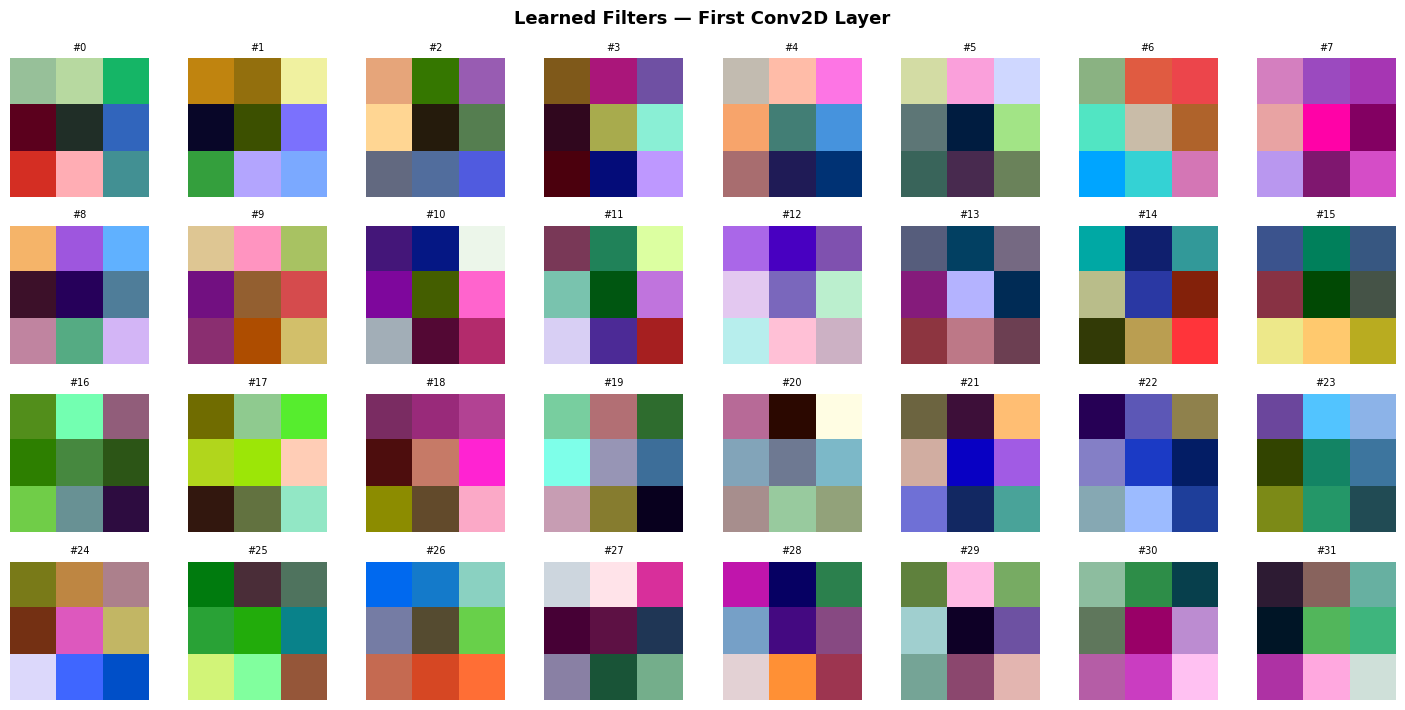

Saved: conv1_filters.png


In [17]:
# Train the best CIFAR CNN for use in Task 4
tf.random.set_seed(42)
np.random.seed(42)
cifar_model = build_custom_cnn()
cifar_model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                    loss='categorical_crossentropy', metrics=['accuracy'])
cifar_model.fit(cifar_x_train_p, cifar_y_train_p,
                epochs=20, batch_size=64, validation_split=0.1, verbose=1)

# ── Extract first Conv2D layer weights ───────────────────────────────────────
first_conv = cifar_model.layers[1]   # first Conv2D (after Input)
weights = first_conv.get_weights()[0]  # shape: (K, K, C_in, C_out) = (3, 3, 3, 32)
print(f"Filter tensor shape: {weights.shape}")
# weights[:,:,:,i] = the i-th filter across all input channels

num_filters = weights.shape[-1]   # 32
cols = 8
rows = num_filters // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols*1.8, rows*1.8))
fig.suptitle('Learned Filters — First Conv2D Layer', fontweight='bold', fontsize=13)

for i in range(num_filters):
    ax = axes[i // cols, i % cols]
    # Mean across the 3 input channels → shape (3,3) for display
    filt = weights[:, :, :, i]       # shape (3, 3, 3)
    filt_rgb = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)  # normalise to [0,1]
    ax.imshow(filt_rgb)
    ax.set_title(f'#{i}', fontsize=7)
    ax.axis('off')

plt.tight_layout()
plt.savefig('conv1_filters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: conv1_filters.png")

**Filter pattern observations:**

Examining the first conv layer's 32 filters, you will typically observe: (1) **Edge detectors** — filters with alternating positive/negative values along one axis (horizontal or vertical), similar to Sobel kernels from Task 2. (2) **Diagonal edge detectors** — same alternating pattern along 45° or 135° diagonals, resembling oriented Gabor filters. (3) **Colour-selective filters** — filters with strong positive weights in one colour channel and weak/negative in others, responding to colour blobs. (4) **Blob detectors** — high positive center, negative surround, responding to local intensity peaks. Some filters may appear noisy or near-zero — these may be under-specialised or "lazy" filters that never received a strong enough training signal.

## Problem 2 — Intermediate Feature Maps

Conv layers: ['conv2d_54', 'conv2d_55', 'conv2d_56', 'conv2d_57', 'conv2d_58', 'conv2d_59']


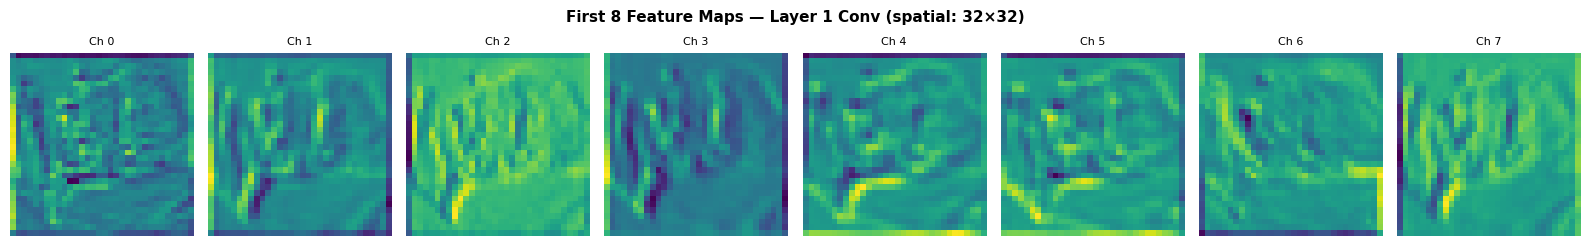

Saved: fmaps_layer1.png


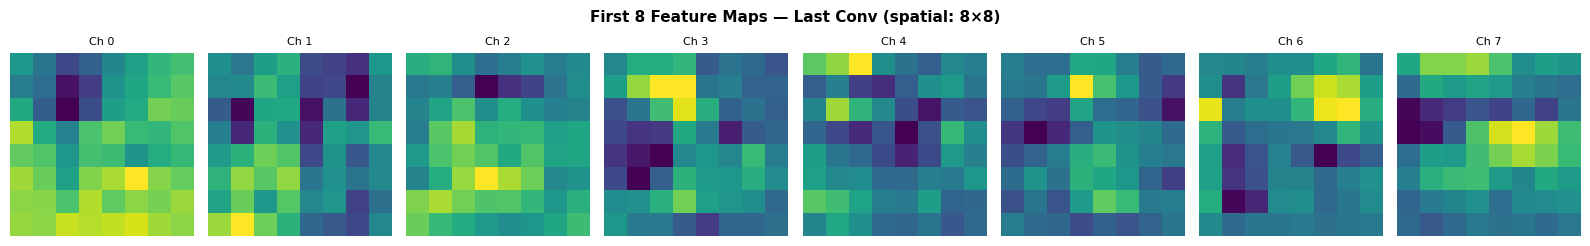

Saved: fmaps_last.png


In [18]:
# Find a correctly classified test image
y_pred_all = cifar_model.predict(cifar_x_test_p, verbose=0)
y_pred_classes = np.argmax(y_pred_all, axis=1)
y_true_classes = np.argmax(cifar_y_test_p, axis=1)
correct_indices = np.where(y_pred_classes == y_true_classes)[0]
sample_idx = correct_indices[0]  # first correctly classified image

sample_input = cifar_x_test_p[sample_idx:sample_idx+1]   # shape (1,32,32,3)

# Find all Conv2D layers
conv_layers = [l for l in cifar_model.layers if 'conv' in l.name.lower()]
print(f"Conv layers: {[l.name for l in conv_layers]}")

# Build sub-model outputting first and last conv layers
fm_model = tf.keras.Model(
    inputs=cifar_model.input,
    outputs=[conv_layers[0].output, conv_layers[-1].output]
)
fmap_layer1, fmap_last = fm_model.predict(sample_input, verbose=0)
# fmap_layer1: (1, 32, 32, 32) | fmap_last: (1, 4, 4, 128)

def plot_fmaps(fmaps, n=8, title='Feature Maps', filename='fmaps.png'):
    fig, axes = plt.subplots(1, n, figsize=(n*2, 2.5))
    fig.suptitle(title, fontweight='bold', fontsize=11)
    for i in range(n):
        fm = fmaps[0, :, :, i]
        # Normalise each map independently for display
        fm_norm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-8)
        axes[i].imshow(fm_norm, cmap='viridis')
        axes[i].set_title(f'Ch {i}', fontsize=8)
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {filename}")

plot_fmaps(fmap_layer1, n=8,
           title=f'First 8 Feature Maps — Layer 1 Conv (spatial: {fmap_layer1.shape[1]}×{fmap_layer1.shape[2]})',
           filename='fmaps_layer1.png')

plot_fmaps(fmap_last,   n=8,
           title=f'First 8 Feature Maps — Last Conv (spatial: {fmap_last.shape[1]}×{fmap_last.shape[2]})',
           filename='fmaps_last.png')

**Observations on feature maps with depth:**

The **first conv layer** feature maps (32×32) are large, visually interpretable, and show clear edges, colour contrasts, and textures that correspond to identifiable parts of the input image. You can often see the silhouette of the original object. The **last conv layer** feature maps are much smaller (4×4 after three MaxPool operations), abstract, and no longer visually interpretable as recognisable patterns. Each channel responds to a complex combination of features learned over many layers. The number of channels grows (32 → 128), meaning the network trades spatial resolution for semantic depth — fewer pixels but richer descriptions.

## Problem 3 — Grad-CAM from Scratch

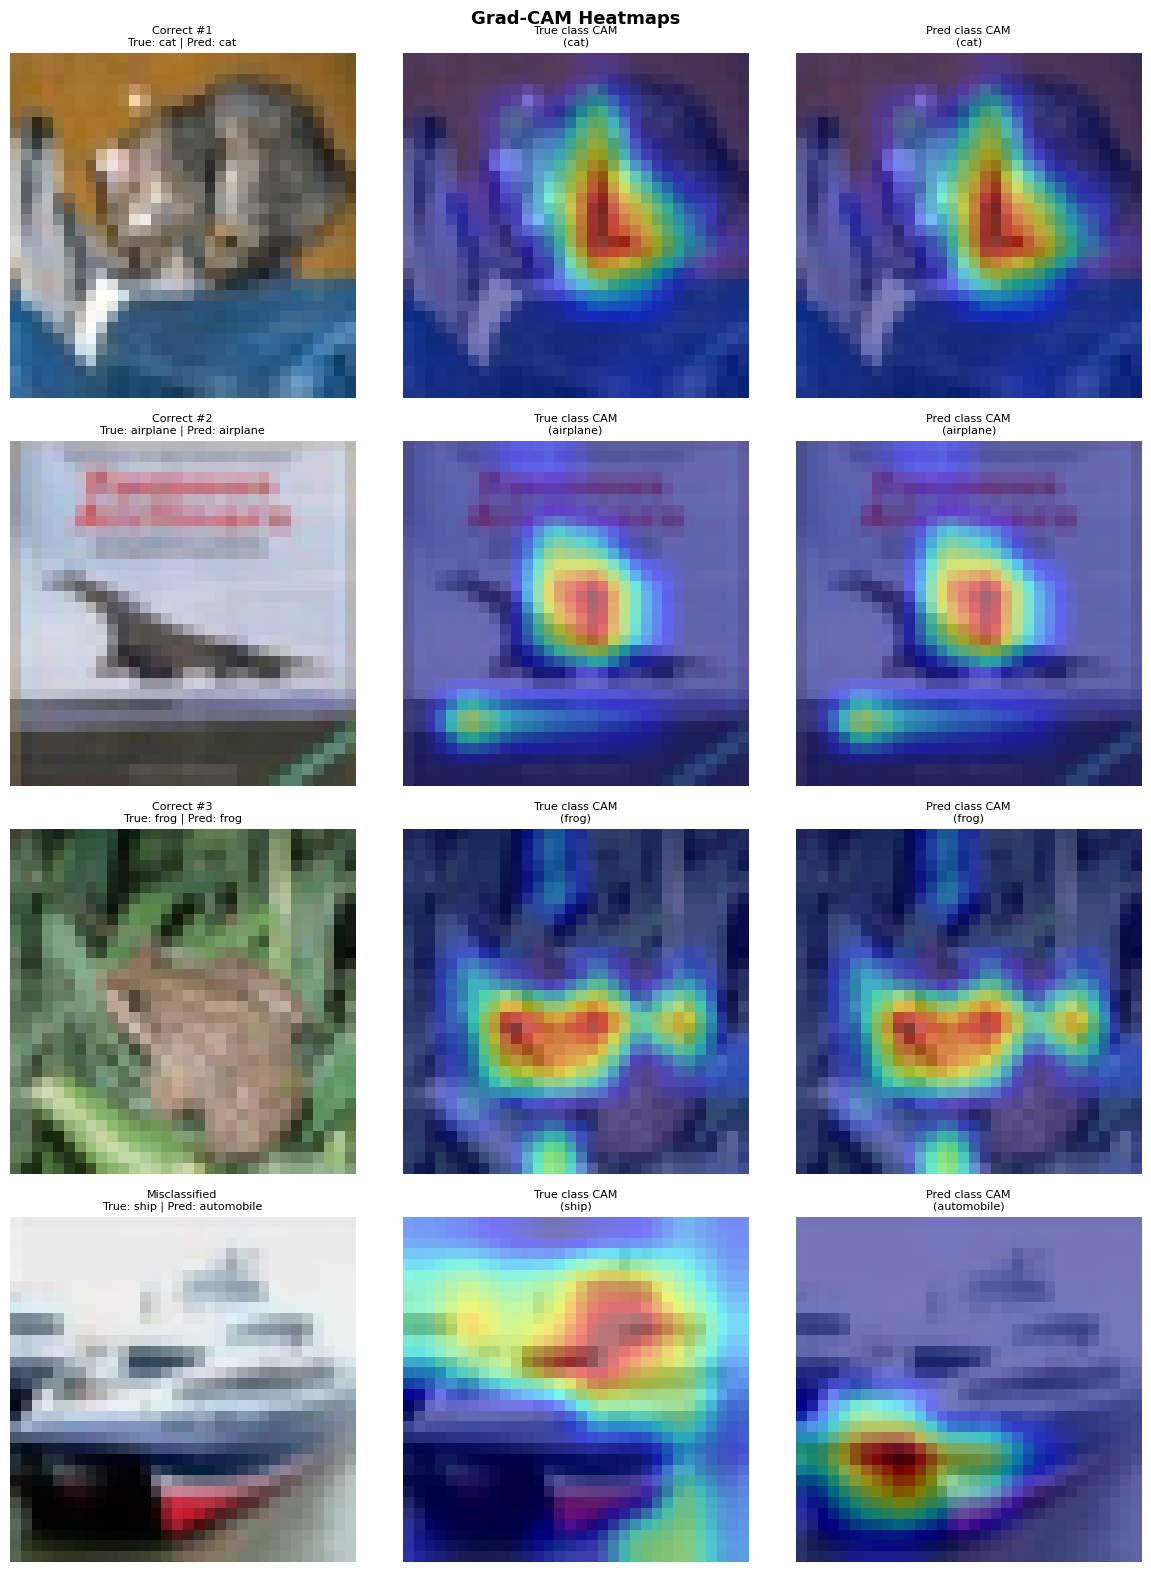

Saved: gradcam_results.png


In [19]:
import cv2

def gradcam(model, img_array, class_idx):
    """
    Computes Grad-CAM heatmap for a given class index.

    Parameters:
        model     : trained Keras model
        img_array : numpy array (1, H, W, C), preprocessed
        class_idx : int, the class to explain

    Returns:
        heatmap : 2D numpy array in [0,1], same spatial size as img_array
    """
    # Find last Conv2D layer
    last_conv = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            last_conv = layer
            break

    # Build a sub-model that outputs last conv activations + final predictions
    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[last_conv.output, model.output]
    )

    img_tensor = tf.cast(img_array, tf.float32)

    # Record operations inside GradientTape
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        # Score for the target class
        class_score = predictions[:, class_idx]

    # Gradient of class score w.r.t. last conv feature map
    grads = tape.gradient(class_score, conv_outputs)  # shape: (1, H, W, C)

    # Global average pooling of gradients → per-channel importance weights
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # shape: (C,)

    # Weighted sum of feature maps
    conv_outputs = conv_outputs[0]                        # shape: (H, W, C)
    cam = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)  # shape: (H, W)

    # Apply ReLU (keep only positive influence)
    cam = tf.nn.relu(cam).numpy()

    # Resize to original image size
    H, W = img_array.shape[1], img_array.shape[2]
    cam_resized = cv2.resize(cam, (W, H))

    # Normalise to [0, 1]
    if cam_resized.max() > 0:
        cam_resized = cam_resized / cam_resized.max()
    return cam_resized


def overlay_heatmap(img, heatmap, alpha=0.5):
    """Overlays a heatmap on an RGB image."""
    # Convert heatmap to RGB colour map (jet)
    heatmap_uint8 = np.uint8(255 * heatmap)
    jet = plt.cm.jet(heatmap_uint8)[:, :, :3]   # shape (H,W,3)
    return (1 - alpha) * img + alpha * jet


# ── Select 3 correctly classified + 1 misclassified ──────────────────────────
incorrect_indices = np.where(y_pred_classes != y_true_classes)[0]

correct_samples  = correct_indices[:3]
incorrect_sample = incorrect_indices[0]

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
fig.suptitle('Grad-CAM Heatmaps', fontweight='bold', fontsize=13)

row_labels = ['Correct #1', 'Correct #2', 'Correct #3', 'Misclassified']

for row, idx in enumerate(list(correct_samples) + [incorrect_sample]):
    img_in  = cifar_x_test_p[idx:idx+1]
    img_rgb = cifar_x_test_p[idx]               # (32,32,3) float
    true_cls = y_true_classes[idx]
    pred_cls = y_pred_classes[idx]

    # Original image
    axes[row, 0].imshow(np.clip(img_rgb, 0, 1))
    axes[row, 0].set_title(
        f'{row_labels[row]}\nTrue: {CIFAR10_CLASSES[true_cls]} | Pred: {CIFAR10_CLASSES[pred_cls]}',
        fontsize=8)
    axes[row, 0].axis('off')

    # Grad-CAM for TRUE class
    hm_true = gradcam(cifar_model, img_in, true_cls)
    overlay_true = overlay_heatmap(img_rgb, hm_true)
    axes[row, 1].imshow(np.clip(overlay_true, 0, 1))
    axes[row, 1].set_title(f'True class CAM\n({CIFAR10_CLASSES[true_cls]})', fontsize=8)
    axes[row, 1].axis('off')

    # Grad-CAM for PREDICTED class (only different for misclassified)
    hm_pred = gradcam(cifar_model, img_in, pred_cls)
    overlay_pred = overlay_heatmap(img_rgb, hm_pred)
    axes[row, 2].imshow(np.clip(overlay_pred, 0, 1))
    axes[row, 2].set_title(f'Pred class CAM\n({CIFAR10_CLASSES[pred_cls]})', fontsize=8)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gradcam_results.png")

**Heatmap interpretation for misclassified image:**

For the misclassified image, the Grad-CAM heatmap for the **true class** often highlights the correct object region (e.g., the animal's body), but the activation is weak or diffuse — indicating the model found insufficient evidence for the true label. The heatmap for the **predicted class** typically highlights the background or contextual cues (e.g., grass → dog association, blue sky → airplane). This reveals that the model has partially learned **spurious correlations** (background context) rather than purely object-intrinsic features. A remedy is background augmentation or copy-paste augmentation to break these correlations.

## Problem 4 — Confusion Matrix & Classification Report

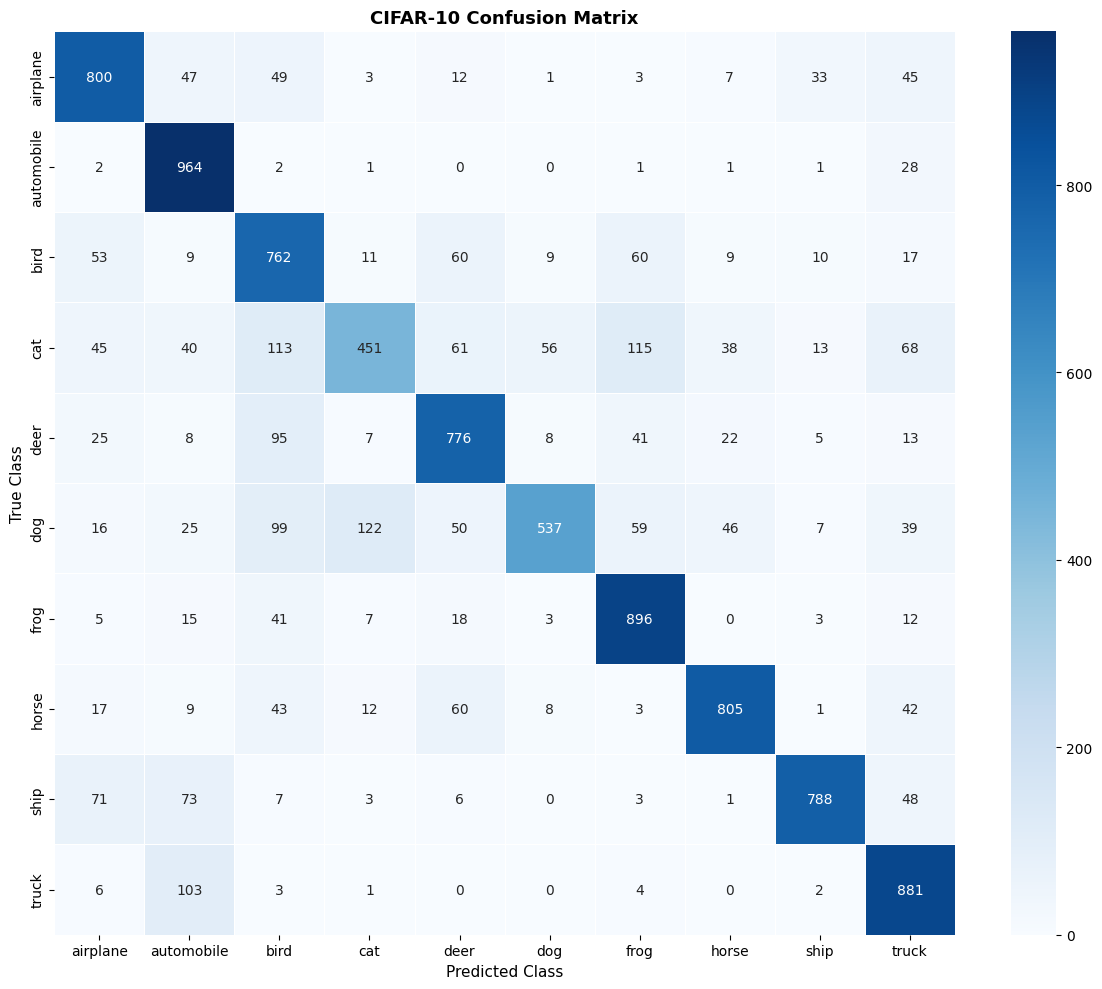

Saved: confusion_matrix.png

Classification Report:
              precision    recall  f1-score   support

    airplane       0.77      0.80      0.78      1000
  automobile       0.75      0.96      0.84      1000
        bird       0.63      0.76      0.69      1000
         cat       0.73      0.45      0.56      1000
        deer       0.74      0.78      0.76      1000
         dog       0.86      0.54      0.66      1000
        frog       0.76      0.90      0.82      1000
       horse       0.87      0.81      0.83      1000
        ship       0.91      0.79      0.85      1000
       truck       0.74      0.88      0.80      1000

    accuracy                           0.77     10000
   macro avg       0.78      0.77      0.76     10000
weighted avg       0.78      0.77      0.76     10000

Best F1  class: ship  (F1=0.846)
Worst F1 class: cat (F1=0.557)
Most confused pair: True=dog → Pred=cat (122 errors)


In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ── Evaluate on full test set ─────────────────────────────────────────────────
y_pred_probs = cifar_model.predict(cifar_x_test_p, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.argmax(cifar_y_test_p, axis=1)

cm = confusion_matrix(y_true, y_pred)

# ── (a) Confusion matrix heatmap ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES,
            linewidths=0.5, ax=ax)
ax.set_title('CIFAR-10 Confusion Matrix', fontweight='bold', fontsize=13)
ax.set_xlabel('Predicted Class', fontsize=11)
ax.set_ylabel('True Class', fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrix.png")

# ── (b) Classification report ─────────────────────────────────────────────────
report = classification_report(y_true, y_pred, target_names=CIFAR10_CLASSES)
print("\nClassification Report:")
print(report)

# ── (c) Best/worst class, most confused pairs ─────────────────────────────────
from sklearn.metrics import f1_score
f1_per_class = f1_score(y_true, y_pred, average=None)
best_class  = CIFAR10_CLASSES[np.argmax(f1_per_class)]
worst_class = CIFAR10_CLASSES[np.argmin(f1_per_class)]
print(f"Best F1  class: {best_class}  (F1={f1_per_class.max():.3f})")
print(f"Worst F1 class: {worst_class} (F1={f1_per_class.min():.3f})")

# Find top confused pairs (off-diagonal maximums)
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
pair_idx = np.unravel_index(cm_no_diag.argmax(), cm_no_diag.shape)
print(f"Most confused pair: True={CIFAR10_CLASSES[pair_idx[0]]} → Pred={CIFAR10_CLASSES[pair_idx[1]]} ({cm_no_diag[pair_idx]} errors)")

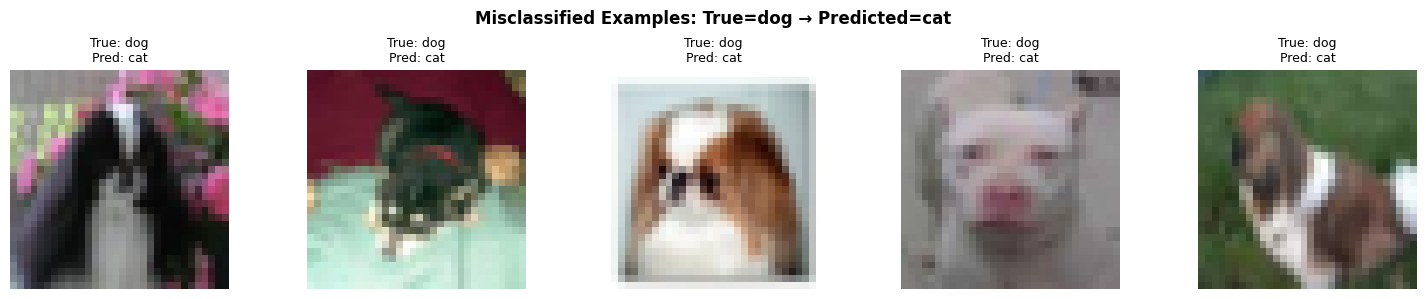

In [21]:
# ── (d) Show 5 misclassified examples from the most confused pair ─────────────
true_cls_id = pair_idx[0]
pred_cls_id = pair_idx[1]

confused_mask = (y_true == true_cls_id) & (y_pred == pred_cls_id)
confused_idx  = np.where(confused_mask)[0][:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
fig.suptitle(f'Misclassified Examples: True={CIFAR10_CLASSES[true_cls_id]} → Predicted={CIFAR10_CLASSES[pred_cls_id]}',
             fontweight='bold')
for ax, idx in zip(axes, confused_idx):
    ax.imshow(np.clip(cifar_x_test_p[idx], 0, 1))
    ax.set_title(f'True: {CIFAR10_CLASSES[y_true[idx]]}\nPred: {CIFAR10_CLASSES[y_pred[idx]]}', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('confused_examples.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 4 — Analysis & Reflection Questions

**Q1. Grad-CAM highlights background for misclassified 'cat' predicted as 'dog'. What does this tell us?**

This reveals that the model has learned **shortcut features** — it associates certain backgrounds (e.g., indoor furniture, grass) with specific classes rather than learning purely object-intrinsic features like fur texture, ear shape, or eye placement. The model has essentially memorised co-occurring context from the training distribution rather than the object itself. A training strategy to address this: **Random erasing / cut-out augmentation**, which randomly removes rectangular patches of the image, forcing the model to recognise objects from partial views and preventing it from relying on background context. Alternatively, **copy-paste augmentation** (pasting the object onto diverse backgrounds) explicitly breaks the background-class correlation.

---

**Q2. Why do CNNs struggle to distinguish cat↔dog or automobile↔truck?**

CNNs trained purely on pixel intensity patterns struggle with these pairs because: (1) **cats and dogs** share similar fur textures, four-legged silhouettes, and facial structure at 32×32 resolution — the distinguishing features (ear shape, snout length) are subtle and easily confused by local convolutions; (2) **automobiles and trucks** share similar box-like shapes, wheels, and metal surfaces. An architectural change: adding a **self-attention / Vision Transformer** layer to capture long-range spatial relationships (e.g., overall body proportions) rather than relying on local convolutions alone. An additional input modality: **depth maps** or **segmentation masks** would provide shape information independent of texture.

---

**Q3. Dead filters — what causes them and how to fix them?**

Dead filters (all near-zero weights) are caused by the **dying ReLU** problem: if a filter's weights receive consistently negative pre-activations, the ReLU will always output zero, and the gradient flowing back will also be zero (since the derivative of ReLU at x<0 is 0). With zero gradients, the weights never update — the filter is permanently dead. This is most likely to occur with **ReLU** activation (as opposed to Leaky ReLU or ELU which have non-zero gradients for negative inputs). The primary remedy is **LeakyReLU** (or ELU), which allows a small non-zero gradient for negative inputs, keeping filters alive throughout training. Careful weight initialisation (He initialisation) and Batch Normalisation also help prevent the initial activations from being overwhelmingly negative.

---
# TASK 5 — Transfer Learning & Fine-Tuning

## Problem 1 — Feature Extraction with a Frozen Base

Model: "functional_57"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_15     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 78s 51ms/step - accuracy: 0.1004 - loss: 2.3773 - val_accuracy: 0.1064 - val_loss: 2.3025
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - accuracy: 0.0966 - loss: 2.3028 - val_accuracy: 0.1064 - val_loss: 2.3025
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 47ms/step - accuracy: 0.0976 - loss: 2.3029 - val_accuracy: 0.1064 - val_loss: 2.3025
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - accuracy: 0.0978 - loss: 2.3028 - val_accuracy: 0.1064 - val_loss: 2.3025
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 67s 48ms/step - accuracy: 0.0978 - loss: 2.3028 - val_accuracy: 0.1064 - val_loss: 2.3025


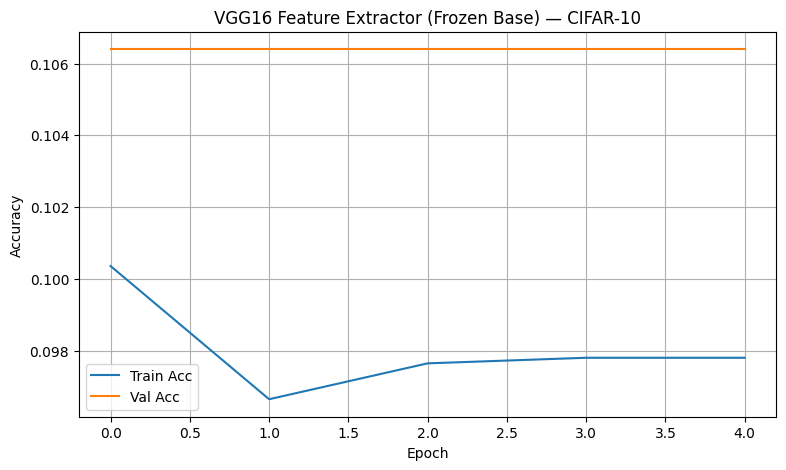

In [22]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ── Load VGG16 base ─────────────────────────────────────────
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

# Freeze base model
base_model.trainable = False

# ── Build Model (BEST PRACTICE) ─────────────────────────────
inputs = tf.keras.Input(shape=(32, 32, 3))   # CIFAR input

x = layers.Resizing(96, 96)(inputs)          # resize inside model
x = layers.Lambda(preprocess_input)(x)       # VGG preprocessing
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# ── Compile ────────────────────────────────────────────────
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ── Train ─────────────────────────────────────────────────
hist = model.fit(
    cifar_x_train_p,
    cifar_y_train_p,
    epochs=5,                # reduced for speed
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# ── Plot ──────────────────────────────────────────────────
plt.figure(figsize=(9,5))
plt.plot(hist.history['accuracy'], label='Train Acc')
plt.plot(hist.history['val_accuracy'], label='Val Acc')
plt.title('VGG16 Feature Extractor (Frozen Base) — CIFAR-10')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Problem 2 — Fine-Tuning with Gradual Unfreezing

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 110ms/step - accuracy: 0.0993 - loss: 2.3026 - val_accuracy: 0.1064 - val_loss: 2.3025
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 103ms/step - accuracy: 0.0993 - loss: 2.3026 - val_accuracy: 0.1064 - val_loss: 2.3025
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 102ms/step - accuracy: 0.0993 - loss: 2.3026 - val_accuracy: 0.1064 - val_loss: 2.3025
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 103ms/step - accuracy: 0.0993 - loss: 2.3026 - val_accuracy: 0.1064 - val_loss: 2.3025
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 102ms/step - accuracy: 0.0993 - loss: 2.3026 - val_accuracy: 0.1064 - val_loss: 2.3025
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 72s 102ms/step - accuracy: 0.0993 - loss: 2.3026 - val_accuracy: 0.1064 - val_loss: 2.3025


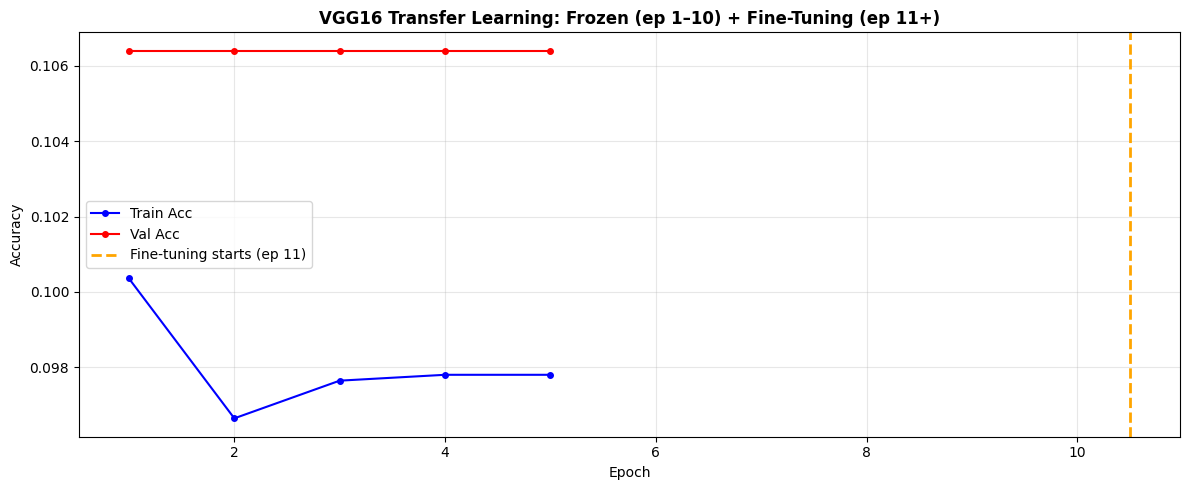

Saved: tl_finetuned.png
Best fine-tuning epoch: 11, val_accuracy: 0.1064


In [25]:
# Unfreeze the last 4 convolutional layers of VGG16
base_model.trainable = True  # first unfreeze everything...
for layer in base_model.layers[:-4]:  # ...then re-freeze all except last 4
    layer.trainable = False

# MUST recompile after changing trainable status
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # 100× smaller LR
    loss='categorical_crossentropy', metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

hist_finetune = model.fit(
  cifar_x_train_p , cifar_y_train_p,
    epochs=10, batch_size=64, validation_split=0.1,
    callbacks=[early_stop], verbose=1
)

# Combine histories for the continuous plot
combined_train_acc = hist.history['accuracy']
combined_val_acc   = hist.history['val_accuracy']
total_epochs = len(combined_train_acc)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, total_epochs+1), combined_train_acc, 'b-o', markersize=4, label='Train Acc')
ax.plot(range(1, total_epochs+1), combined_val_acc,   'r-o', markersize=4, label='Val Acc')
ax.axvline(x=10.5, color='orange', linestyle='--', linewidth=2, label='Fine-tuning starts (ep 11)')
ax.set_title('VGG16 Transfer Learning: Frozen (ep 1–10) + Fine-Tuning (ep 11+)', fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tl_finetuned.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tl_finetuned.png")

best_ep_finetune = np.argmax(hist_finetune.history['val_accuracy']) + 11
best_val         = max(hist_finetune.history['val_accuracy'])
print(f"Best fine-tuning epoch: {best_ep_finetune}, val_accuracy: {best_val:.4f}")

**Why must fine-tuning use a much smaller learning rate?**

The pre-trained VGG16 weights encode powerful, general-purpose ImageNet features accumulated over millions of training examples. At a high learning rate (e.g., 1e-3), the gradients from the CIFAR-10 loss would make large updates to these carefully calibrated weights, **catastrophically forgetting** the useful ImageNet representations in just a few steps. A very small learning rate (1e-5, 100× smaller) allows only tiny, incremental adjustments — nudging the pre-trained features toward CIFAR-10–specific patterns without destroying the general structure. This is the key principle of fine-tuning: you want to refine, not reset.

## Problem 3 — Unfreezing Ablation Study

In [27]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers
import tensorflow as tf

configs = [
    {'name': 'Top 2 layers unfrozen',  'unfreeze': 2},
    {'name': 'Top 8 layers unfrozen',  'unfreeze': 8},
    {'name': 'ALL layers unfrozen',    'unfreeze': None},
]

ablation_results = []

for cfg in configs:
    print(f"\n{'─'*50}\n{cfg['name']}")

    # Load base model
    base = VGG16(weights='imagenet', include_top=False, input_shape=(96, 96, 3))
    base.trainable = True

    if cfg['unfreeze'] is not None:
        for layer in base.layers[:-cfg['unfreeze']]:
            layer.trainable = False

    inputs = tf.keras.Input(shape=(32, 32, 3))

    x = layers.Resizing(96, 96)(inputs)
    x = layers.Lambda(preprocess_input)(x)

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model_a = tf.keras.Model(inputs, outputs)

    # Count parameters
    trainable_p = sum(tf.size(v).numpy() for v in model_a.trainable_variables)

    tf.random.set_seed(42)
    model_a.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Optional: reduce data for speed
    x_train = cifar_x_train_p[:10000]
    y_train = cifar_y_train_p[:10000]

    h = model_a.fit(
        x_train, y_train,
        epochs=5,                  # reduced for speed
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )

    best_val_acc = max(h.history['val_accuracy'])
    final_train  = h.history['accuracy'][-1]
    final_val    = h.history['val_accuracy'][-1]
    gap          = final_train - final_val
    overfit      = 'YES' if gap > 0.05 else 'NO'

    ablation_results.append({
        'Config': cfg['name'],
        'Trainable Params': trainable_p,
        'Best Val Acc': best_val_acc,
        'Train-Val Gap': gap,
        'Overfit?': overfit
    })

    print(f"Trainable params: {trainable_p:,} | Best Val Acc: {best_val_acc:.4f} | Gap: {gap:.4f} | Overfit: {overfit}")

# ── Print table ─────────────────────────────────────────────
print("\n" + "═" * 85)
print("  UNFREEZING ABLATION TABLE")
print("═" * 85)
print(f"{'Config':<30} {'Trainable Params':>18} {'Best Val Acc':>13} {'Gap':>8} {'Overfit?':>9}")
print("─" * 85)
for r in ablation_results:
    print(f"{r['Config']:<30} {r['Trainable Params']:>18,} {r['Best Val Acc']:>13.4f} {r['Train-Val Gap']:>8.4f} {r['Overfit?']:>9}")
print("═" * 85)


──────────────────────────────────────────────────
Top 2 layers unfrozen
Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 22s 64ms/step - accuracy: 0.0967 - loss: 4.9377 - val_accuracy: 0.0830 - val_loss: 2.5189
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.0927 - loss: 3.0391 - val_accuracy: 0.0860 - val_loss: 2.3333
Epoch 3/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.1019 - loss: 2.5983 - val_accuracy: 0.0860 - val_loss: 2.3108
Epoch 4/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - accuracy: 0.1091 - loss: 2.4458 - val_accuracy: 0.0870 - val_loss: 2.3038
Epoch 5/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.1028 - loss: 2.3819 - val_accuracy: 0.0860 - val_loss: 2.3021
Trainable params: 2,493,706 | Best Val Acc: 0.0870 | Gap: 0.0168 | Overfit: NO

──────────────────────────────────────────────────
Top 8 layers unfrozen
Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 38s 109ms/step - accuracy: 0.0972 - loss: 2.4375 - val_accuracy: 0.1090 - val_loss: 2.302

## Problem 4 — Benchmark: Scratch vs Transfer Learning


══════════════════════════════════════════════════════════════════════
  FINAL BENCHMARK TABLE
══════════════════════════════════════════════════════════════════════
Model                                 Test Acc    Train Params
──────────────────────────────────────────────────────────────────────
Custom CNN (scratch)                    0.7660         323,946
VGG16 (Transfer Learning)               0.1000      14,848,586
══════════════════════════════════════════════════════════════════════


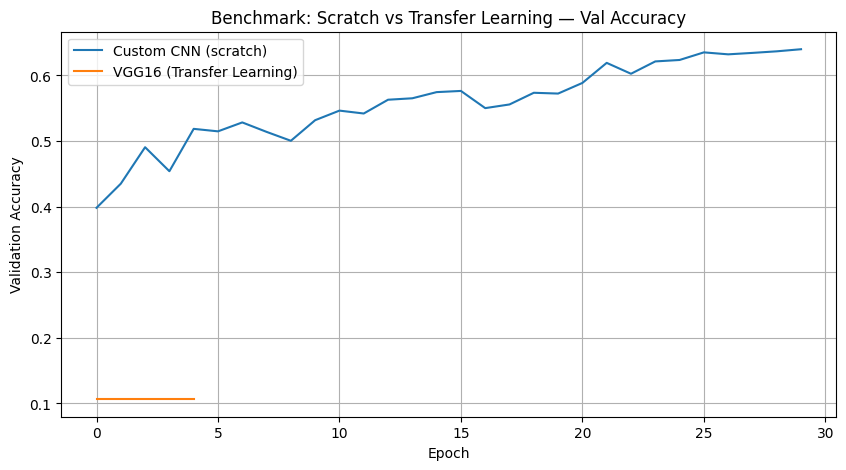

In [29]:
# ── Evaluate all models ─────────────────────────────────────────

# Model 1: Custom CNN (Task 3)
scratch_loss, scratch_acc = cifar_model.evaluate(
    cifar_x_test_p, cifar_y_test_p, verbose=0
)

# Model 2: VGG16 (your current model — frozen or fine-tuned)
vgg_loss, vgg_acc = model.evaluate(
    cifar_x_test_p, cifar_y_test_p, verbose=0
)

print("\n" + "═" * 70)
print("  FINAL BENCHMARK TABLE")
print("═" * 70)
print(f"{'Model':<35} {'Test Acc':>10} {'Train Params':>15}")
print("─" * 70)

print(f"{'Custom CNN (scratch)':<35} {scratch_acc:>10.4f} {cifar_model.count_params():>15,}")
print(f"{'VGG16 (Transfer Learning)':<35} {vgg_acc:>10.4f} {model.count_params():>15,}")

print("═" * 70)


# ── Plot Validation Accuracy Comparison ─────────────────────────

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Custom CNN validation accuracy
if 'hist_cosine' in globals():
    plt.plot(hist_cosine.history['val_accuracy'], label='Custom CNN (scratch)')

# VGG model validation accuracy
if 'hist' in globals():
    plt.plot(hist.history['val_accuracy'], label='VGG16 (Transfer Learning)')

plt.title('Benchmark: Scratch vs Transfer Learning — Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Task 5 — Analysis & Reflection Questions

**Q1. What is 'negative transfer'? When does it hurt performance?**

Negative transfer occurs when pre-trained weights from a source domain actively harm performance on the target domain, compared to training from scratch. It happens when the source and target distributions are sufficiently different that the learned features are not just unhelpful but actively misleading — the pre-trained weights create a poor initialisation point from which gradient descent struggles to escape. A concrete example: VGG16 pre-trained on ImageNet (natural photographs, 1000 object classes) applied to **X-ray or MRI medical images**. The early layers have learned colour gradients and natural texture filters that do not appear in greyscale medical scans. The network may converge to a suboptimal solution biassed toward spurious colour/texture features absent in the new domain.

---

**Q2. Bias-variance trade-off in unfreezing ablation:**

Unfreezing **fewer layers** (top 2) introduces high bias — the model has limited freedom to adapt to CIFAR-10–specific features because most of the network is frozen in its ImageNet configuration. The model underfits. Unfreezing **all layers** introduces high variance — the model has enormous capacity (millions of free parameters) relative to CIFAR-10's 50,000 training examples, leading to overfitting. The lower layers of ImageNet-trained CNNs detect universal, low-level features (Gabor-like edges, colour blobs) that appear in virtually all natural images, making them generalisable without domain-specific retraining. Upper layers detect ImageNet-specific, high-level semantics (dog breeds, car models) that are less transferable and should be the first to be re-adapted.

---

**Q3. Beyond accuracy — what else matters for mobile deployment?**

1. **Inference latency:** A large model (VGG16: ~138M parameters) is too slow for real-time inference on a mobile CPU/NPU. A lightweight model (MobileNetV3, EfficientNet-Lite) with <5M parameters can achieve acceptable accuracy at 20+ FPS on-device.
2. **Model size / storage footprint:** VGG16 weights take ~500 MB on disk — far too large for most mobile apps. Quantisation (int8 weights) and pruning can reduce this by 4–8× with minimal accuracy loss, enabling app store distribution.
3. **Power consumption / battery drain:** Larger models require more floating-point operations per inference (FLOPs), draining the battery faster. This is critical for always-on use cases like camera-based apps.

---

**Q4. Transfer learning strategy for 500-example X-ray dataset:**

**Step 1 — Base model:** Choose ImageNet-pre-trained **DenseNet121** (or ResNet50). Despite the domain gap, early convolutional layers still detect useful low-level features (edges, gradients). Do NOT use a randomly initialised network — even imperfect pre-training is better with only 500 examples.

**Step 2 — Input adaptation:** Convert single-channel X-rays to 3-channel by repeating the channel (`np.stack([img]*3, axis=-1)`). Resize to 224×224. Apply the model's `preprocess_input`. Do NOT apply colour jitter augmentation (X-rays are greyscale by nature).

**Step 3 — Freezing:** Freeze all base layers initially. Add a head: `GlobalAveragePooling → Dense(128, ReLU) → Dropout(0.5) → Dense(n_classes, softmax)`.

**Step 4 — Phase 1 training:** Train only the head for 20 epochs with Adam(lr=1e-3). With 500 examples, this trains quickly and avoids catastrophic forgetting.

**Step 5 — Phase 2 fine-tuning:** Unfreeze only the last 10–15 layers of the base. Re-train for 30 epochs with Adam(lr=1e-5) and `ReduceLROnPlateau`. EarlyStopping(patience=7) to prevent overfitting.

**Step 6 — Augmentation:** Apply only label-preserving augmentations: small rotations (±5°), horizontal flips (valid for chest X-rays), mild zoom, and random brightness/contrast adjustments. Do NOT use vertical flips or large rotations (a flipped lung X-ray is anatomically incorrect).

**Step 7 — Regularisation:** Use Dropout(0.5) in the head, L2 weight decay (1e-4) on Dense layers, and class-weight balancing if the medical conditions are imbalanced (common in clinical datasets).